In [1]:
import polars as pl

# Regression computation -- L2-Arctic, SAA, OpenSLR


In [19]:
result_frame = pl.read_csv("post_rebuttal_results/scores_asr.csv")

print(result_frame['dataset'].unique())
print(result_frame.columns)
print(result_frame['model'].unique())

shape: (12,)
Series: 'dataset' [str]
[
	"TIMIT"
	"Openslr70"
	"ISLE"
	"SAA"
	"L2-Arctic"
	…
	"L2-Arctic Spontaneous"
	"BELC"
	"L1-Arctic"
	"CORAAL"
	"Openslr83"
]
['dataset', 'model', 'release_date', 'sample_id', 'native_language', 'groundtruth', 'prediction', 'wer', 'cer']
shape: (16,)
Series: 'model' [str]
[
	"OWSM 3.1 1B"
	"Whisper Large v3"
	"Deepspeech"
	"OWSM 2.0 739M"
	"Qwen3 ASR 1.7B"
	…
	"Whisper Large v2"
	"MMS 1B All"
	"Whisper Large v1"
	"SeamlessM4T"
	"OWSM 4.0 1B"
]


In [21]:
# sort the models by release_date
result_frame.sort('release_date')['model'].unique(maintain_order=True)
# print the models in the order of release date, with index
for i, model in enumerate(result_frame.sort('release_date')['model'].unique(maintain_order=True)):
    print(f"{i+1}. {model}")




1. Deepspeech
2. WavLM Libri-100h
3. Whisper Large v1
4. Whisper Large v2
5. MMS 1B All
6. OWSM 1.0 272M
7. OWSM 2.0 739M
8. Whisper Large v3
9. SeamlessM4T
10. OWSM 3.1 1B
11. Qwen2 Audio 7B
12. OWSM 4.0 1B
13. Qwen3 ASR 1.7B
14. Canary Qwen 2.5B
15. Google Chirp 3
16. Omnilingual 7B


In [22]:
# concatenate a copy of the L1-Arctic dataset's English portion to the result frame, but label it as L2-Arctic so that we can use it as the standard
l1_arctic_english = result_frame.filter(pl.col('dataset') == 'L1-Arctic')\
    .filter(pl.col('native_language') == 'USA')\
    .with_columns([pl.lit('L2-Arctic').alias('dataset')])
l1_arctic_english
result_frame = pl.concat([result_frame, l1_arctic_english])

In [24]:
all_models = result_frame['model'].unique().to_list()
print(all_models)

['Canary Qwen 2.5B', 'OWSM 4.0 1B', 'Qwen3 ASR 1.7B', 'OWSM 3.1 1B', 'Qwen2 Audio 7B', 'Omnilingual 7B', 'Whisper Large v3', 'OWSM 2.0 739M', 'Deepspeech', 'MMS 1B All', 'Google Chirp 3', 'Whisper Large v1', 'OWSM 1.0 272M', 'Whisper Large v2', 'WavLM Libri-100h', 'SeamlessM4T']


In [23]:
import numpy as np
from typing import Dict
from datetime import datetime

def obtain_model_to_release_dict() -> Dict:
    frame_dict = result_frame.select(['release_date', 'model'])\
        .unique(['release_date', 'model']).to_dict()
    model_to_release_dict = {}
    for i in range(len(frame_dict['release_date'])):
        year, month = frame_dict['release_date'][i].split('-')
        year, month = int(year), int(month)
        day = 1
        model_to_release_dict[frame_dict['model'][i]] = datetime(year, month, day)
    return model_to_release_dict

def obtain_pre_post_wers(dataset_frame, model_prev, model_after):
    model_to_release_dict = obtain_model_to_release_dict()
    assert model_to_release_dict[model_after] > model_to_release_dict[model_prev] 
    target_cols = ['sample_id', 'wer'] 
    model_prev_frame = dataset_frame.filter(pl.col('model') == model_prev)\
        .select(target_cols).unique('sample_id')
    model_after_frame = dataset_frame.filter(pl.col('model') == model_after)\
        .select(target_cols).unique('sample_id')
    # assert len(model_prev_frame) == len(model_after_frame), f"mismatched sample counts between models: {len(model_prev_frame)} ({model_prev}) \n{len(model_after_frame)} ({model_after})"
    # sample_matched_frame = model_prev_frame.join(model_after_frame, on='sample_id')
    # assert sample_matched_frame.height > 0, f"no overlapping samples between models: {model_prev_frame}\n{model_after_frame}"
    # differences = sample_matched_frame['wer_right'] - sample_matched_frame['wer'] # positive means the WER is higher -- worse.
    return model_prev_frame['wer'], model_after_frame['wer']

def compute_mean_differences(dataset_frame, model_prev, model_after):
    model_to_release_dict = obtain_model_to_release_dict()
    assert model_to_release_dict[model_after] > model_to_release_dict[model_prev] 
    prev_wers, pre_wers = obtain_pre_post_wers(dataset_frame, model_prev, model_after)
    # median_diff = differences.median()
    return np.average(pre_wers) - np.average(prev_wers)

def get_all_pre_post_pairs():
    pre_post_pairs = []
    model_to_release_dict = obtain_model_to_release_dict()
    for model, release_date in model_to_release_dict.items():
        for other_model, other_date in model_to_release_dict.items():
            if other_date < release_date:
                pre_post_pairs.append((other_model, model))
    for prev_model, post_model in pre_post_pairs:
        assert model_to_release_dict[prev_model] < model_to_release_dict[post_model]
    return pre_post_pairs

In [25]:
DATASET_2_PAIR_MAPPING = {
    'L2-Arctic': {
        'minority': 'Vietnamese',
        'standard': 'USA'
    },
    'L2-Arctic Spontaneous': {
        'minority': 'Korean',
        'standard': 'USA'
    },
    'SAA': {
        'standard': 'English',
        'minority': 'Korean'
    },
    'Openslr83': {
        'minority': 'Irish English',
        'standard': 'Southern English'
    }
}

In [26]:
def bootstrap_sample_id(
    df: pl.DataFrame,
    seed: int,
    group_col: str = "native_language",
    sample_col: str = "sample_id",
) -> pl.DataFrame:
    """
    Bootstrap sample `sample_col` within each `group_col`,
    keeping group sizes fixed.
    """
    return (
        df
        .group_by(group_col)\
            .map_groups(
            lambda g: g.sample(
                n=len(g),
                with_replacement=True,
                seed=seed,
            )
        )
    )

In [27]:
def preprocess_saa_frame(all_results_frame):
    # only keep language backgrounds with 10 or more samples
    saa_frame = all_results_frame.filter(pl.col('dataset') == 'SAA')\
            .filter(pl.col('model')=='Whisper Large v1')
    assert len(saa_frame) != 0
    saa_frame = saa_frame.join(
        saa_frame.group_by('native_language').agg(pl.count('sample_id').alias('count')),
        on='native_language'
    ).filter(pl.col('count') > 20).drop('count')
    language_backgrounds = saa_frame['native_language'].unique().to_list()
    return all_results_frame.filter(pl.col('dataset') == 'SAA')\
        .filter(pl.col('native_language').is_in(language_backgrounds))

def get_max_avg_wer_for_language_background(frame):
    # group by language background and model compute the average, and then average across the models for each language background
    avg_wer_frame = frame.group_by(['native_language', 'model']).agg(pl.mean('wer').alias('avg_wer'))
    avg_wer_frame = avg_wer_frame.group_by('native_language').agg(pl.mean('avg_wer').alias('mean_of_avg_wer'))
    return avg_wer_frame

def get_regression_size_for_models(frame, dataset, accent, 
                                   prev_model, 
                                   post_model):
    accent_frame = frame.filter(pl.col('dataset') == dataset)\
        .filter(pl.col('native_language') == accent)
    prev_wers, post_wers = obtain_pre_post_wers(accent_frame, prev_model, post_model)
    # filter out wers > 1
    prev_wers = prev_wers.filter(prev_wers <= 1)
    post_wers = post_wers.filter(post_wers <= 1)
    # compute the regression size
    avg_prev_wer = np.average(prev_wers)
    avg_post_wer = np.average(post_wers)
    regression_size = avg_post_wer - avg_prev_wer
    return regression_size

saa_frame = preprocess_saa_frame(result_frame)
print(saa_frame['native_language'].unique())
# print(get_max_avg_wer_for_language_background(saa_frame).sort('mean_of_avg_wer', descending=True))

shape: (12,)
Series: 'native_language' [str]
[
	"Arabic"
	"Spanish"
	"Russian"
	"Italian"
	"English"
	…
	"Turkish"
	"French"
	"Korean"
	"Dutch"
	"Portuguese"
]


In [33]:

get_regression_size_for_models(result_frame, 'L2-Arctic', 'USA', 'Whisper Large v2', 'MMS 1B All')

np.float64(0.013104277258689026)

In [229]:
saa_frame['model'][0]

'Whisper Large v1'

In [10]:
!pip install loguru

  Using cached loguru-0.7.3-py3-none-any.whl (61 kB)


In [31]:
from tqdm import tqdm
import loguru
logger = loguru.logger
pre_post_pairs = get_all_pre_post_pairs()
num_models = len(obtain_model_to_release_dict())

def bootstrap_significance_test(wer_differences): # TODO: may want to use a weak bayesian prior here...
    assert np.average(wer_differences) > 0
    num_better = 0
    for b in range(1000):
        worse_sample = np.random.choice(wer_differences, size=len(wer_differences), replace=True)
        if np.average(worse_sample) >= 0:
            num_better += 1
    p_value = 1 - num_better / 1000.0
    return p_value

def compute_biggest_difference_for_background(frame, background):
    frame = frame.filter(pl.col('native_language') == background)
    significant_regression_pairs = []
    for prev_model, post_model in pre_post_pairs:
        try:
            current_difference = compute_mean_differences(frame, prev_model, post_model)
        except AssertionError as e:
            print(e)
            logger.warning(f"Could not compute difference between {prev_model} and {post_model} for background {background}. No overlapping samples?")
            continue
        if current_difference > 0:
            significant_regression_pairs.append((prev_model, post_model, current_difference))
    return significant_regression_pairs
# print the list of significant regression pairs 

def compute_normalized_regression_for_background(frame, background):
    significant_regression_pairs = compute_biggest_difference_for_background(frame, background)
    num_regressions = len(significant_regression_pairs)
    total_regression= np.sum([x[2] for x in significant_regression_pairs]) if len(significant_regression_pairs) > 0 else 0
    # normalized_regression = total_regression / (num_models * (num_models - 1) / 2)
    if total_regression == 0:
        return 0, 0
    else:
        normalized_regression = total_regression / len(significant_regression_pairs)
        return normalized_regression, num_regressions

def compare_normalized_regressions_for_standard_and_minority(dataset, 
                                                             dataset_result_frame, 
                                                             standard_background, 
                                                             minority_background,
                                                             compute_significance=False):
    assert standard_background in dataset_result_frame['native_language'].unique().to_list(), f"Standard background {standard_background} not found in dataset; available backgrounds: {dataset_result_frame['native_language'].unique().to_list()}"
    assert minority_background in dataset_result_frame['native_language'].unique().to_list(), f"Minority background {minority_background} not found in dataset; available backgrounds: {dataset_result_frame['native_language'].unique().to_list()}"
    standard_normalized_regression, standard_num_regressions = compute_normalized_regression_for_background(
        dataset_result_frame, 
        standard_background)
    minority_normalized_regression, minority_num_regressions = compute_normalized_regression_for_background(
        dataset_result_frame, minority_background)
    print(f"Dataset: {dataset}")
    print(f"Minority background: {minority_background} - Normalized regression: {minority_normalized_regression:.6f} - Num regressions: {minority_num_regressions}")
    print(f"Standard background: {standard_background} - Normalized regression: {standard_normalized_regression:.6f} - Num regressions: {standard_num_regressions}")

    # check if the difference is significant by doing B=1000 bootstrap samples

    if compute_significance:
        print("Running signficance test...")
        num_minority_worse = 0
        num_bootstrap_samples = 1000
        minority_frame = dataset_result_frame.filter(pl.col('native_language') == minority_background)
        standard_frame = dataset_result_frame.filter(pl.col('native_language') == standard_background)
        assert minority_frame.height > 0, f"No samples found for minority background {minority_background}"
        assert standard_frame.height > 0, f"No samples found for standard background {standard_background}"
        for b in tqdm(range(num_bootstrap_samples)):
        # resample the dataset frame with replacement
            standard_resampled_normalized_regression, num_standard_regressions = compute_normalized_regression_for_background(
            # standard_frame.sample(n=standard_frame.height, with_replacement=True),
                bootstrap_sample_id(standard_frame, seed=b, group_col='model'), 
                standard_background)
            minority_resampled_normalized_regression, num_minority_regressions = compute_normalized_regression_for_background(
            # minority_frame.sample(n=minority_frame.height, with_replacement=True),
            bootstrap_sample_id(minority_frame, seed=b, group_col='model'),
                minority_background)
            if b % 100 == 0:
                print(f"Bootstrap sample {b}: Standard normalized regression: {standard_resampled_normalized_regression:.3f}, Minority normalized regression: {minority_resampled_normalized_regression:.3f}")
            if minority_resampled_normalized_regression * (num_minority_regressions / 120)  > standard_resampled_normalized_regression * (num_standard_regressions / 120):
                num_minority_worse += 1
        p_value = 1 - (num_minority_worse / num_bootstrap_samples)
        print(f"P-value for minority background having higher normalized regression than standard background: {p_value:.4f}")


def compute_language_background_ordinal_rankings(dataset_result_frame, 
                                                standard_background,
                                                minority_background):
    backgrounds = dataset_result_frame['native_language'].unique().to_list()
    background_to_normalized_regression = {}

    for background in backgrounds:
        normalized_regression, num_regressions = compute_normalized_regression_for_background(
            dataset_result_frame, background)
        background_to_normalized_regression[background] = normalized_regression * num_regressions
    # sort the backgrounds by normalized regression
    sorted_backgrounds = sorted(background_to_normalized_regression.items(), key=lambda x: x[1])
    # print the ranking of the standard and minority backgrounds
    for rank, (background, normalized_regression) in enumerate(sorted_backgrounds):
        if background == standard_background:
            standard_rank = rank + 1
        if background == minority_background:
            minority_rank = rank + 1
    print(f"Minority background {minority_background} rank: {minority_rank}/{len(backgrounds)}")
    print(f"Standard background {standard_background} rank: {standard_rank}/{len(backgrounds)}")

    # do a significance test that English is always in the top 50% of backgrounds
    num_better = 0
    num_bootstrap_samples = 1000
    for b in tqdm(range(num_bootstrap_samples)):
        # TODO: replace with conditional resampling.
        # resampled_frame = dataset_result_frame.sample(n=dataset_result_frame.height, with_replacement=True)
        background = standard_background
        resampled_frame = bootstrap_sample_id(dataset_result_frame, seed=b, group_col='model')
        normalized_regression, num_regressions = compute_normalized_regression_for_background(
            resampled_frame, background)
        background_to_normalized_regression[background] = normalized_regression
        sorted_backgrounds = sorted(background_to_normalized_regression.items(), key=lambda x: x[1])
        for rank, (background, normalized_regression) in enumerate(sorted_backgrounds):
            if background == standard_background:
                standard_rank = rank + 1
        if standard_rank <= len(backgrounds) / 2:
            num_better += 1
    # print the ordinal rank significance p-value
    p_value = 1 - (num_better / num_bootstrap_samples)
    print(f"P-value for standard background {standard_background} being in top 50% of backgrounds: {p_value:.4f}")
    print('========')

In [32]:
for dataset_name, backgrounds in DATASET_2_PAIR_MAPPING.items():
    if dataset_name == 'SAA':
        dataset_frame = preprocess_saa_frame(result_frame)
    elif dataset_name == 'L2-Arctic':
        continue
    else:
        dataset_frame = result_frame.filter(pl.col('dataset') == dataset_name)
    standard_background = backgrounds['standard']
    minority_background = backgrounds['minority']
    compare_normalized_regressions_for_standard_and_minority(
        dataset_name, dataset_frame, standard_background, minority_background,
        # compute_significance=True
    )
    compute_language_background_ordinal_rankings(
        dataset_frame, standard_background, minority_background
    )

Dataset: L2-Arctic Spontaneous
Minority background: Korean - Normalized regression: 0.098035 - Num regressions: 33
Standard background: USA - Normalized regression: 0.075113 - Num regressions: 13
Minority background Korean rank: 3/7
Standard background USA rank: 1/7


100%|██████████| 1000/1000 [12:09<00:00,  1.37it/s]


P-value for standard background USA being in top 50% of backgrounds: 0.0000
Dataset: SAA
Minority background: Korean - Normalized regression: 0.116715 - Num regressions: 30
Standard background: English - Normalized regression: 0.115855 - Num regressions: 23
Minority background Korean rank: 7/12
Standard background English rank: 2/12


  6%|▌         | 55/1000 [00:40<12:22,  1.27it/s]

## Finding individual examples 

In [337]:
def get_prev_post_wer_sorted_frame(dataset_name, 
                                   prev_model, 
                                   post_model, language_background):
    # filter the result frame to the dataset
    dataset_frame = result_frame.filter(pl.col('dataset') == dataset_name)\
        .filter(pl.col('native_language') == language_background)
    # then get the pre and post WERs
    prev_model_frame = dataset_frame.filter(pl.col('model') == prev_model)
    post_model_frame = dataset_frame.filter(pl.col('model') == post_model)
    # join on sample IDs
    merged_frame = prev_model_frame.join(
        post_model_frame, 
        on='sample_id', 
        suffix='_post'
    ).select([
        pl.col('sample_id'),
        pl.col('native_language'),
        pl.col('wer').alias('wer_prev'),
        pl.col('wer_post'), 
        pl.col('prediction'), 
        pl.col('prediction_post'),
        pl.col('groundtruth')
    ])
    # create a new column which is the wer_post - wer_prev
    merged_frame = merged_frame.with_columns([
        (pl.col('wer_post') - pl.col('wer_prev')).alias('wer_post_minus_wer_prev')
    ])
    # sort by wer_post_minus_wer_prev in descending order
    merged_frame = merged_frame.sort('wer_post_minus_wer_prev', descending=True).head(len(merged_frame) // 4)
    return merged_frame

def print_random_row(frame, prev_model, later_model):
    # get a random row 
    random_row = frame.sample(n=1, with_replacement=False)
    # print the filepath
    print("ID: ", random_row['sample_id'][0])
    print("\n\n\n\n\n\n\n\n")
    # print the whisper v1 text and the canary text
    print(f"{prev_model} Normalized Text: ", random_row[f'prediction'][0]) 
    print(f"{later_model} Text: ", random_row[f'prediction_post'][0])
    print(f"Ground truth: ", random_row[f'groundtruth'][0])

### L2-Arctic

In [281]:
prev_model = 'Whisper Large v2'
post_model = 'MMS 1B All'
example_sorted_frame = get_prev_post_wer_sorted_frame(
    'L2-Arctic', 
    prev_model, 
    post_model,
    'Vietnamese'
    ) 
example_sorted_frame.columns
print_random_row(example_sorted_frame, prev_model, post_model)
get_regression_size_for_models(result_frame, 'L2-Arctic', 'Vietnamese', prev_model, post_model)

ID:  3263









Whisper Large v2 Normalized Text:   Without a doubt, some of them have dinner engagements.
MMS 1B All Text:  withour doubt some of them have dinner engagements
Ground truth:  without a doubt some of them have dinner engagements


0.12524056924848936

### L2-Arctic Spontaneous

In [315]:
result_frame['model'].unique().to_list()

['MMS 1B All',
 'Whisper Large v1',
 'WavLM Libri-100h',
 'Deepspeech',
 'Qwen2 Audio 7B',
 'Canary Qwen 2.5B',
 'Whisper Large v2',
 'Omnilingual 7B',
 'OWSM 3.1 1B',
 'Google Chirp 3',
 'Whisper Large v3']

In [335]:
prev_model = "Canary Qwen 2.5B"
post_model = "Omnilingual 7B"
dataset = "L2-Arctic Spontaneous"
accent = 'Korean'
example_sorted_frame = get_prev_post_wer_sorted_frame(
    dataset, 
    prev_model, 
    post_model,
    accent
    ) 
example_sorted_frame.columns
print_random_row(example_sorted_frame, prev_model, post_model)
get_regression_size_for_models(result_frame, dataset, accent, prev_model, post_model)

ID:  19









Canary Qwen 2.5B Normalized Text:  Okay, um I can see skyscrapers tall buildings and I think
Omnilingual 7B Text:  i can see skyscripers tall buildings and i think
Ground truth:  ok uh i can see skra skyscrapers tall buildings and i


0.1540792540792541

### Openslr83 - Irish English


In [338]:
prev_model = "Google Chirp 3"
post_model = "Omnilingual 7B"
dataset = "Openslr83"
accent = 'Irish English'
example_sorted_frame = get_prev_post_wer_sorted_frame(
    dataset, 
    prev_model, 
    post_model,
    accent
    ) 
example_sorted_frame.columns
print_random_row(example_sorted_frame, prev_model, post_model)
get_regression_size_for_models(result_frame, dataset, accent, prev_model, post_model)

ID:  2879









Google Chirp 3 Normalized Text:  Your app facilitates or promotes content that includes gratuitous violence or dangerous activities.
Omnilingual 7B Text:  your off facilitates or promotes content that includes gratuitous flylence or dangerous activities
Ground truth:  Your app facilitates or promotes content that includes gratuitous violence or dangerous activities


0.05691467713640362

### SAA


In [340]:
prev_model = "Whisper Large v2"
post_model = "MMS 1B All"
dataset = "SAA"
accent = 'Korean'
example_sorted_frame = get_prev_post_wer_sorted_frame(
    dataset, 
    prev_model, 
    post_model,
    accent
    ) 
example_sorted_frame.columns
print_random_row(example_sorted_frame, prev_model, post_model)
get_regression_size_for_models(result_frame, dataset, accent, prev_model, post_model)

ID:  715









Whisper Large v2 Normalized Text:   Please call Stella. Ask her to bring these things with her from the store.
MMS 1B All Text:  please costella escr to bring these things with her from the store
Ground truth:  please call stella Ask her to bring these things with her from the


0.18379423236127215

In [64]:
dataset_frame['model'].unique().to_list()

['OWSM 2.0 739M',
 'MMS 1B All',
 'OWSM 4.0 1B',
 'Google Chirp 3',
 'Qwen2 Audio 7B',
 'Omnilingual 7B',
 'Whisper Large v2',
 'Whisper Large v1',
 'SeamlessM4T',
 'WavLM Libri-100h',
 'OWSM 1.0 272M',
 'Canary Qwen 2.5B',
 'Deepspeech',
 'Whisper Large v3',
 'Qwen3 ASR 1.7B',
 'OWSM 3.1 1B']

# Gap-correlation measure

/var/folders/4s/lb1vnqls41q48r0glrfkkhnm0000gn/T/ipykernel_67762/59859946.py:25: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  dataset_frame
/var/folders/4s/lb1vnqls41q48r0glrfkkhnm0000gn/T/ipykernel_67762/59859946.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(release_dates, rotation=45, ha='right')
/var/folders/4s/lb1vnqls41q48r0glrfkkhnm0000gn/T/ipykernel_67762/59859946.py:25: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  dataset_frame
/var/folders/4s/lb1vnqls41q48r0glrfkkhnm0000gn/T/ipykernel_67762/59859946.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(release_dates, rotation=45, ha='right')
/var/folders/4s/lb1vnqls

Linear fit R^2: 0.612
Direction changes for L2-Arctic: 8
Linear fit R^2: 0.000
Direction changes for L2-Arctic Spontaneous: 8
Linear fit R^2: 0.443
Direction changes for SAA: 7
Linear fit R^2: 0.396
Direction changes for Openslr83: 9


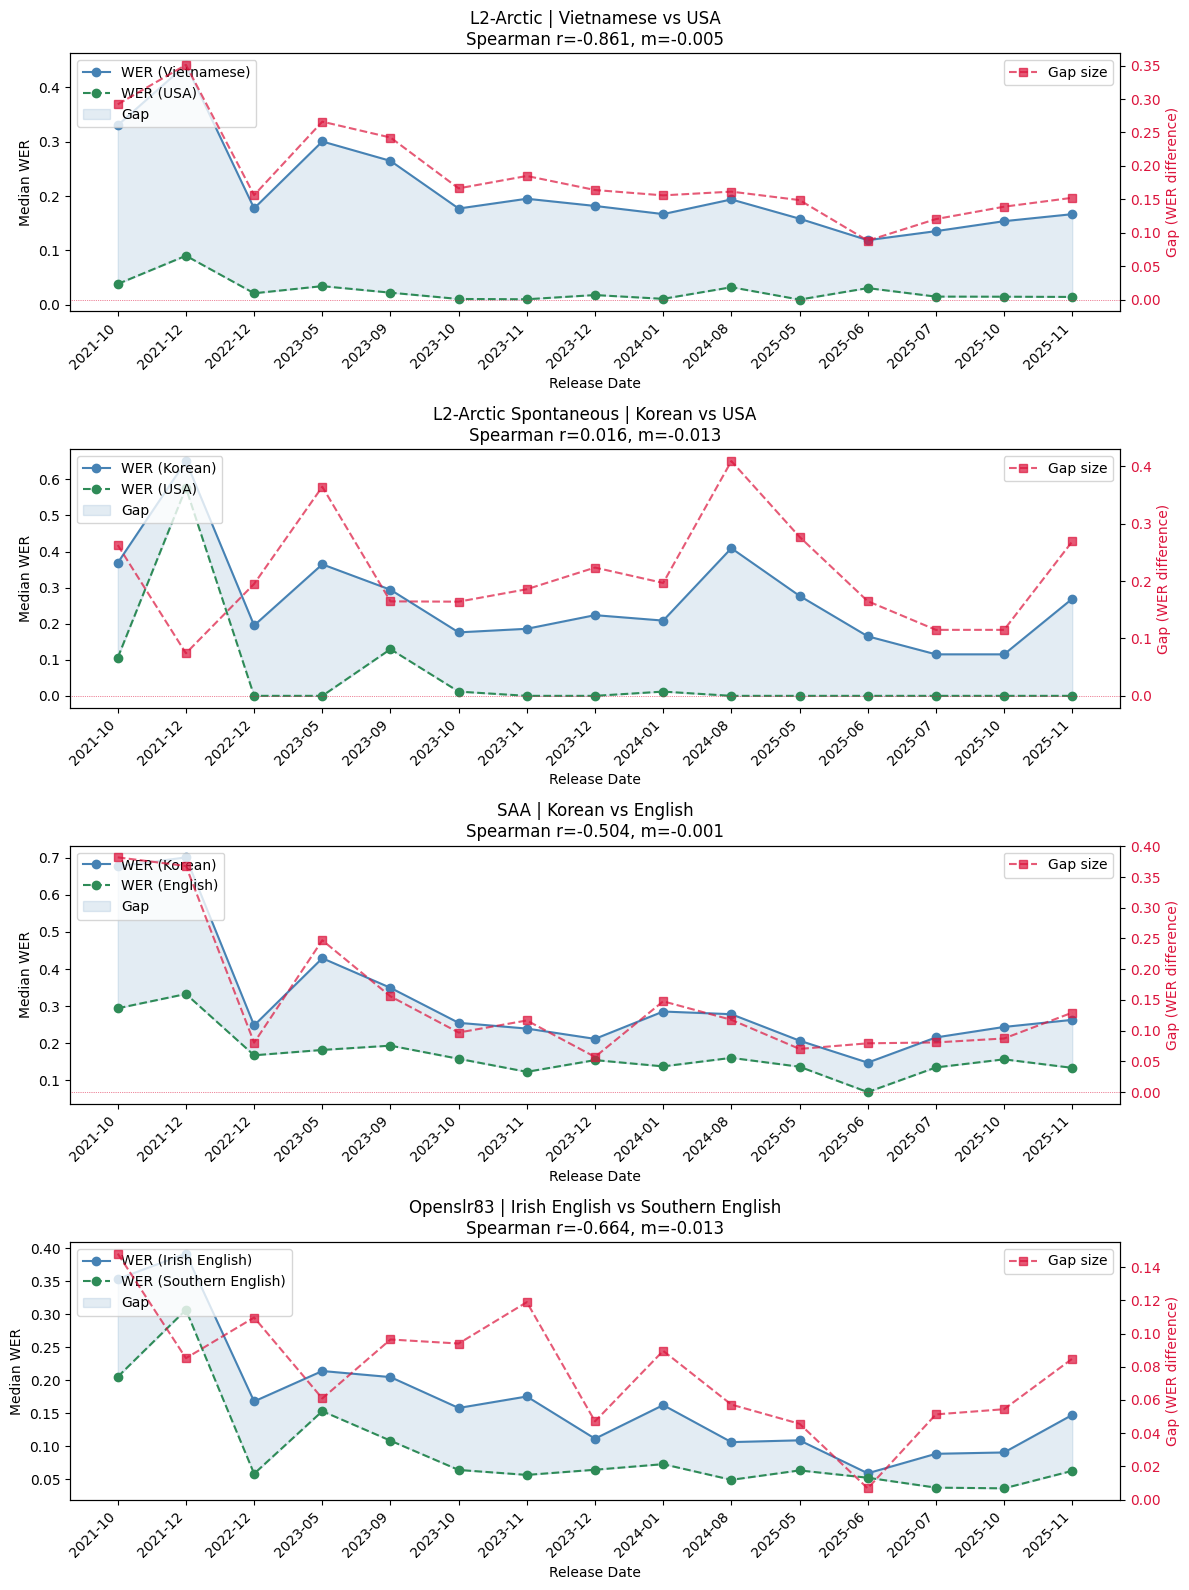

In [32]:
from sklearn.linear_model import HuberRegressor
from matplotlib import pyplot as plt
from scipy import stats

fig, axes = plt.subplots(len(DATASET_2_PAIR_MAPPING), 1, 
                          figsize=(12, 4 * len(DATASET_2_PAIR_MAPPING)))

# for dataset_name, backgrounds in DATASET_2_PAIR_MAPPING.items():
for ax, (dataset_name, backgrounds) in zip(axes, DATASET_2_PAIR_MAPPING.items()):

    if dataset_name == 'SAA':
        dataset_frame = preprocess_saa_frame(result_frame)
    else:
        dataset_frame = result_frame.filter(pl.col('dataset') == dataset_name)
    
    dataset_frame = dataset_frame.filter(pl.col('model') != 'Whisper Large v1')
    
    minority_background = backgrounds['minority']
    standard_background = backgrounds['standard']

    # compute the gap size between the standard and minority background for each model release.
    # Just use the median WER for each background to compute the gap size, since the mean can be skewed by outliers and we want to get a sense of the typical gap size that a user might experience.

    gap_frame = (
        dataset_frame
        .filter(pl.col('native_language').is_in([minority_background, standard_background]))
        .group_by(['release_date', 'native_language'])
        .agg(pl.col('wer').mean().alias('median_wer'))
        # .pivot(index='release_date', on='native_language', values='median_wer')
        .pivot(index='release_date', columns='native_language', values='median_wer')
        .with_columns(
            (pl.col(minority_background) - pl.col(standard_background)).alias('gap')
        )
        .sort('release_date')
    )

    x = np.array(release_index, dtype=float)
    y = np.array(gap_values)

    huber = HuberRegressor()
    huber.fit(x.reshape(-1, 1), y)
    predicted = huber.predict(x.reshape(-1, 1))
    m = huber.coef_[0]
    release_dates = gap_frame['release_date'].to_list()
    release_index = list(range(len(gap_frame)))
    gap_values = gap_frame['gap'].to_list()
    minority_wer = gap_frame[minority_background].to_list()
    standard_wer = gap_frame[standard_background].to_list()

    spearman_corr, p_value = stats.spearmanr(release_index, gap_values)
    rho, p_value = stats.spearmanr(release_index, gap_values)
    # m, b = np.polyfit(x, gap_values, 1)

    # Linear fit
    x = np.array(release_index, dtype=float)
    y = np.array(gap_values)
    linear_coeffs = np.polyfit(x, y, 1)
    linear_pred = np.polyval(linear_coeffs, x)
    ss_res = np.sum((y - linear_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    linear_r2 = 1 - ss_res / ss_tot
    print(f"Linear fit R^2: {linear_r2:.3f}")


    # Plot WER lines
    ax.plot(release_dates, minority_wer, 'o-', color='steelblue', label=f'WER ({minority_background})')
    ax.plot(release_dates, standard_wer, 'o--', color='seagreen', label=f'WER ({standard_background})')
    
    # Shade the gap
    ax.fill_between(release_dates, minority_wer, standard_wer, alpha=0.15, color='steelblue', label='Gap')

    # Overlay gap as a separate line
    ax2 = ax.twinx()
    ax2.plot(release_dates, gap_values, 's--', color='crimson', alpha=0.7, label='Gap size')
    ax2.set_ylabel('Gap (WER difference)', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    ax2.axhline(0, color='crimson', linewidth=0.5, linestyle=':')

    ax.set_title(f'{dataset_name} | {minority_background} vs {standard_background}\n'
                 f'Spearman r={spearman_corr:.3f}, m={m:.3f}')
    ax.set_xlabel('Release Date')
    ax.set_ylabel('Median WER')
    ax.set_xticklabels(release_dates, rotation=45, ha='right')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

    deltas = np.diff(gap_values)
    sign_changes = np.sum(np.diff(np.sign(deltas)) != 0)
    print(f"Direction changes for {dataset_name}: {sign_changes}")

plt.tight_layout()
plt.savefig('gap_over_time.png', dpi=150, bbox_inches='tight')
plt.show()


# Within-family analysis

In [168]:
# 1. Deepspeech
# 2. WavLM Libri-100h
# 3. Whisper Large v1
# 4. Whisper Large v2
# 5. MMS 1B All
# 6. OWSM 1.0 272M
# 7. OWSM 2.0 739M
# 8. Whisper Large v3
# 9. SeamlessM4T
# 10. OWSM 3.1 1B
# 11. Qwen2 Audio 7B
# 12. OWSM 4.0 1B
# 13. Qwen3 ASR 1.7B
# 14. Canary Qwen 2.5B
# 15. Google Chirp 3
# 16. Omnilingual 7B

FAMILIES = {
    "WHISPER": ['Whisper Large v1', 'Whisper Large v2', 'Whisper Large v3'],
    "META": ["MMS 1B All", "SeamlessM4T", "Omnilingual 7B"], 
    "OWSM": ["OWSM 1.0 272M", "OWSM 2.0 739M", "OWSM 3.1 1B", "OWSM 4.0 1B"],
    "QWEN": ["Qwen2 Audio 7B", "Qwen3 ASR 1.7B", "Canary Qwen 2.5B"],
}

/var/folders/4s/lb1vnqls41q48r0glrfkkhnm0000gn/T/ipykernel_4529/245289581.py:7: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.
  saa_frame.groupby('native_language').agg(pl.count('sample_id').alias('count')),


WHISPER - Average gap increase size for spikes: 5.23%
WHISPER - Pearson r: -0.312, p-value: 0.004
META - Average gap increase size for spikes: 3.62%
META - Pearson r: -0.307, p-value: 0.004
OWSM - Average gap increase size for spikes: 2.76%
OWSM - Pearson r: -0.198, p-value: 0.036
QWEN - Average gap increase size for spikes: 2.61%
QWEN - Pearson r: -0.263, p-value: 0.016


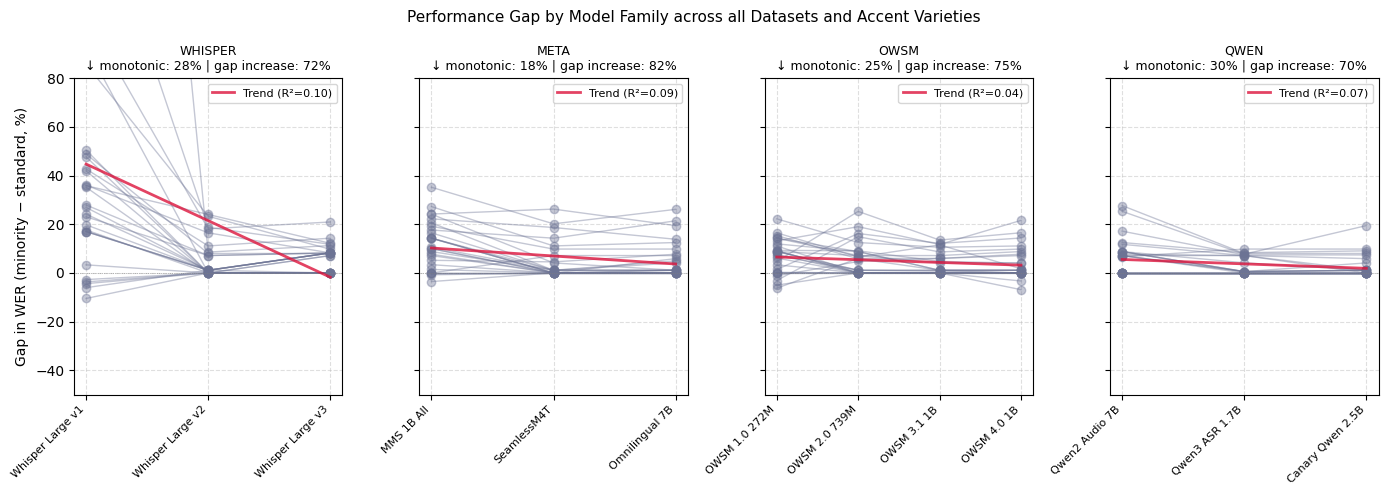

In [171]:
from cycler import cycler
from scipy.stats import pearsonr, spearmanr

plt.style.use('seaborn-v0_8-colorblind')


# Get current property cycle (the seaborn colorblind palette)
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# Add an extra color
extra_color = "#6C7394"  
colors.append(extra_color)

# Set the new color cycle
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
UNCONDITIONAL_COLOR = colors[-1]

fig, axes = plt.subplots(1, len(FAMILIES), figsize=(14, 5), sharey=True)

# combine DATASET_2_PAIR_MAPPING

for ax, (family_name, family_models) in zip(axes, FAMILIES.items()):
    
    gap_increase_sizes = []
    n_monotonic = 0
    n_spike = 0
    all_x = []
    all_gaps = []

    for dataset_name, backgrounds in DATASET_2_PAIR_MAPPING.items():
        
        if dataset_name == 'SAA':
            dataset_frame = preprocess_saa_frame(result_frame)
        else:
            dataset_frame = result_frame.filter(pl.col('dataset') == dataset_name)
        # multiply WER by 100
        dataset_frame = dataset_frame.with_columns(pl.col('wer') * 100)
        
        standard_background = backgrounds['standard']
        
        family_frame = dataset_frame.filter(pl.col('model').is_in(family_models))
        
        if family_frame.is_empty():
            continue

        all_accents = family_frame['native_language'].unique().to_list()
        minority_accents = [a for a in all_accents if a != standard_background]

        standard_frame = (
            family_frame
            .filter(pl.col('native_language') == standard_background)
            .group_by(['model', 'release_date'])
            .agg(pl.col('wer').median().alias('median_wer'))
            .sort('release_date')
        )

        for accent in minority_accents:
            minority_frame = (
                family_frame
                .filter(pl.col('native_language') == accent)
                .group_by(['model', 'release_date'])
                .agg(pl.col('wer').median().alias('median_wer'))
                .sort('release_date')
            )

            merged = minority_frame.join(standard_frame, on=['model', 'release_date'], suffix='_standard')
            
            if len(merged) < 2:
                continue
            
            merged = merged.with_columns(
                (pl.col('median_wer') - pl.col('median_wer_standard')).alias('gap')
            ).sort('release_date')

            gap = merged['gap'].to_list()
            deltas = [gap[i+1] - gap[i] for i in range(len(gap) - 1)]

            # Monotonic decrease: all deltas negative
            if all(d < 0 for d in deltas):
                n_monotonic += 1
            # Spike: any increase at positions 2, 3, or 4 (i.e. delta index 1, 2, 3)
            elif any(deltas[i] > 0 for i in range(1, len(deltas))):
                n_spike += 1

            gap_increase_sizes.extend([d for i, d in enumerate(deltas) if i >= 1 and d > 0])
            x = list(range(len(merged)))
            gap_vals = merged['gap'].to_list()
            all_x.extend(x)
            all_gaps.extend(gap_vals)
            ax.plot(x, gap_vals, 'o-', alpha=0.4, linewidth=1, color=UNCONDITIONAL_COLOR)

    total = n_monotonic + n_spike
    pct_monotonic = 100 * n_monotonic / total if total > 0 else 0
    pct_spike = 100 * n_spike / total if total > 0 else 0
    # avg gap increase size for spikes
    avg_gap_increase = np.mean(gap_increase_sizes) 
    print(f"{family_name} - Average gap increase size for spikes: {avg_gap_increase:.2f}%")

    ax.set_xticks(range(len(family_models)))
    ax.set_xticklabels(family_models, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"{family_name}\n↓ monotonic: {pct_monotonic:.0f}% | gap increase: {pct_spike:.0f}%", fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    # set ylim to -0.5 to 0.8
    ax.set_ylim(-50, 80)
    ax.grid(True, linestyle='--', alpha=0.4)

    all_x = np.array(all_x)
    all_gaps = np.array(all_gaps)
    
    ax.legend(fontsize=8)

    #Make sure all_x and all_gaps are reset to [] at the start of each family loop, not inside


axes[0].set_ylabel('Gap in WER (minority − standard, %)')
fig.suptitle('Performance Gap by Model Family across all Datasets and Accent Varieties', fontsize=11)
plt.tight_layout()
# save high quality figure
plt.savefig('family_gap_trends.png', dpi=300, bbox_inches='tight')
plt.show()

# Regression computation -- ALLSTAR

## Preprocessing dataframe

In [19]:
import polars as pl

# df = pl.read_csv("allstar_wer_1128_filtered.csv")
df = pl.read_csv("post_rebuttal_results/allstar_wer_0314_filtered.csv")

# Extract model names from the normalized_text_* columns
norm_cols = [c for c in df.columns if c.startswith("normalized_text_")]
wer_cols  = [c for c in df.columns if c.startswith("wer_")]

# Get raw model identifiers (e.g. "whisper_large_v1")
models = [c.replace("normalized_text_", "") for c in norm_cols]

# Create maps for both normalized_text and WER lookup
norm_map = {m: f"normalized_text_{m}" for m in models}
wer_map  = {m: f"wer_{m}" for m in models}


# --------- YOUR TARGET LABELS ---------
model_map = {
    "owsm_3_1": "OWSM 3.1 1B",
    "qwen2_audio": "Qwen2 Audio 7B",
    "whisper_large_v1": "Whisper Large v1",
    "whisper_large_v2": "Whisper Large v2",
    "whisper_large_v3": "Whisper Large v3",
    "canary_qwen_2_5b": "Canary Qwen 2.5B",
    "mms_1b_all": "MMS 1B All",
    "google_chirp_3": "Google Chirp 3",
    "omni": "Omnilingual 7B",
    "deepspeech": "Deepspeech",
    "wavlm": "WavLM Libri-100h",
}
# --------------------------------------


# ---- MELT into long format with both normalized text + WER ----
melted = (
    df
    .select([
        # keep id vars
        *(c for c in df.columns if not c.startswith("normalized_text_") and not c.startswith("wer_")),

        # extract model values into struct columns
        *[
            pl.struct([
                pl.col(norm_map[m]).alias("normalized_text"),
                pl.col(wer_map[m]).alias("wer"),
            ]).alias(f"model_{m}")
            for m in models
        ]
    ])
    # melt struct columns
    .melt(
        id_vars=[c for c in df.columns if not c.startswith("normalized_text_") and not c.startswith("wer_")],
        value_vars=[f"model_{m}" for m in models],
        variable_name="model",
        value_name="data",
    )
    # unpack struct
    .unnest("data")
    # clean model name
    .with_columns(
        pl.col("model")
        .str.replace("model_", "")
        .replace(model_map)
        .alias("model")
    )
)
melted

/var/folders/4s/lb1vnqls41q48r0glrfkkhnm0000gn/T/ipykernel_67762/2859060732.py:37: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  df


filepath,speaker,gender,l1,task,text,text_normalized,model,normalized_text,wer
str,i64,str,str,str,str,str,str,str,f64
"""segmented_audio/ALL_CCT_ENG_DH…",73,"""M""","""CCT""","""DHR""","""NO ONE SHALL BE SUBJECTED TO T…","""no one shall be subjected to t…","""Whisper Large v1""","""no one shall be subjected to t…",0.0625
"""segmented_audio/ALL_CCT_ENG_DH…",73,"""M""","""CCT""","""DHR""","""NO ONE SHALL BE SUBJECTED TO T…","""no one shall be subjected to t…","""Whisper Large v1""","""no one shall be subjected to t…",0.0625
"""segmented_audio/ALL_CCT_ENG_DH…",73,"""M""","""CCT""","""DHR""","""EVERYONE HAS THE RIGHT TO FREE…","""everyone has the right to free…","""Whisper Large v1""","""everyone has the right to free…",0.090909
"""segmented_audio/ALL_CCT_ENG_DH…",73,"""M""","""CCT""","""DHR""","""EVERYONE HAS THE RIGHT TO FREE…","""everyone has the right to free…","""Whisper Large v1""","""everyone has the right to free…",0.090909
"""segmented_audio/ALL_CCT_ENG_DH…",73,"""M""","""CCT""","""DHR""","""EVERYONE HAS THE RIGHT TO REST…","""everyone has the right to rest…","""Whisper Large v1""","""everyone has the right to rest…",0.052632
…,…,…,…,…,…,…,…,…,…
"""segmented_audio/ALL_VIE_ENG_LP…",146,"""F""","""VIE""","""LPP""","""I AM RIGHT HERE THE VOICE SAID…","""i am right here the voice said…","""qwen3_audio""","""the little prince what do you …",1.0
"""segmented_audio/ALL_VIE_ENG_LP…",146,"""F""","""VIE""","""LPP""","""IT WAS NOW THE EIGHTH DAY SINC…","""it was now the 8th day since i…","""qwen3_audio""","""and i had listened to the stor…",0.805556
"""segmented_audio/ALL_VIE_ENG_LP…",146,"""F""","""VIE""","""LPP""","""IT WAS NOW THE EIGHTH DAY SINC…","""it was now the 8th day since i…","""qwen3_audio""","""and i had listened to the stor…",0.805556


In [37]:
# speechbox_frame = pl.read_csv('allstar_results_for_plotting_1203.csv')
speechbox_frame = pl.read_csv('post_rebuttal_results/allstar_results_for_plotting_0314.csv')
# multiply wers by 100
speechbox_frame = speechbox_frame.with_columns(pl.col('wer') * 100)
print(speechbox_frame.columns)
print(speechbox_frame['task'].unique())
# create a new column 'dataset' which is dataset + '_{task}', from the task row
print(speechbox_frame['dataset'].unique())
speechbox_frame = speechbox_frame.with_columns([
    (pl.col('dataset') + '_' + pl.col('task')).alias('dataset_task')
])

['dataset', 'model', 'release_date', 'sample_id', 'native_language', 'task', 'groundtruth', 'prediction', 'wer', 'cer']
shape: (4,)
Series: 'task' [str]
[
	"DHR"
	"HT2"
	"LPP"
	"HT1"
]
shape: (1,)
Series: 'dataset' [str]
[
	"ALLSTAR"
]


In [22]:
speechbox_frame.filter(pl.col('dataset_task') == 'ALLSTAR_LPP')\
    .filter(pl.col('native_language')=='VIE')\
    .filter(pl.col('sample_id')==22631)

dataset,model,release_date,sample_id,native_language,task,groundtruth,prediction,wer,cer,dataset_task
str,str,str,i64,str,str,str,str,f64,f64,str


In [21]:
SPEECHBOX_2_PAIR_MAPPING = {
    'ALLSTAR_LPP': {
        'standard': 'ENG',
        'minority': 'VIE'
    }, 
    'ALLSTAR_DHR': {
        'standard': 'ENG',
        'minority': 'CCT'
    }, 
    'ALLSTAR_HT1': {
        'standard': 'ENG', 
        'minority': 'RUN'
    }, 
    'ALLSTAR_HT2': {
        'standard': 'ENG',
        'minority': 'RUN'
    }
}

In [99]:
for dataset_name, backgrounds in SPEECHBOX_2_PAIR_MAPPING.items():
    dataset_frame = speechbox_frame.filter(pl.col('dataset_task') == dataset_name)
    standard_background = backgrounds['standard']
    minority_background = backgrounds['minority']
    compare_normalized_regressions_for_standard_and_minority(
        dataset_name, dataset_frame, standard_background, minority_background
    )
    compute_language_background_ordinal_rankings(
        dataset_frame, standard_background, minority_background
    )

/Users/smfsamir/mac_env/lib/python3.8/site-packages/numpy/lib/function_base.py:518: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/smfsamir/mac_env/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


Dataset: ALLSTAR_LPP
Minority background: VIE - Normalized regression: 0.036184 - Num regressions: 39
Standard background: ENG - Normalized regression: 0.025260 - Num regressions: 43
Minority background VIE rank: 4/22
Standard background ENG rank: 3/22
Dataset: ALLSTAR_DHR
Minority background: CCT - Normalized regression: 0.038628 - Num regressions: 41
Standard background: ENG - Normalized regression: 0.012979 - Num regressions: 42
Minority background CCT rank: 17/21
Standard background ENG rank: 3/21
Dataset: ALLSTAR_HT1
Minority background: RUN - Normalized regression: 0.122400 - Num regressions: 33
Standard background: ENG - Normalized regression: 0.023511 - Num regressions: 42
Minority background RUN rank: 21/22
Standard background ENG rank: 2/22
Dataset: ALLSTAR_HT2
Minority background: RUN - Normalized regression: 0.144167 - Num regressions: 40
Standard background: ENG - Normalized regression: 0.026427 - Num regressions: 41
Minority background RUN rank: 22/22
Standard background 

In [47]:
df_plot = (
    speechbox_frame
    .filter(pl.col('dataset_task') == dataset_name)
    .filter(pl.col('native_language') == minority_background)
    .group_by(['release_date', 'model'])
    .agg(pl.col('wer').mean())
    .sort('release_date')
)

In [58]:
###################### Plotting Style ######################
from cycler import cycler

plt.style.use('seaborn-v0_8-colorblind')

# Get current property cycle (the seaborn colorblind palette)
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# Add an extra color
extra_color = "#6C7394"  
colors.append(extra_color)

# Set the new color cycle
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)

# higher resolution
plt.rcParams['figure.dpi'] = 300
UNCONDITIONAL_COLOR = colors[-1]

In [63]:
speechbox_frame['wer'].mean()

10.275398684058656

## Gap measure

/var/folders/4s/lb1vnqls41q48r0glrfkkhnm0000gn/T/ipykernel_67762/660946607.py:33: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  dataset_frame


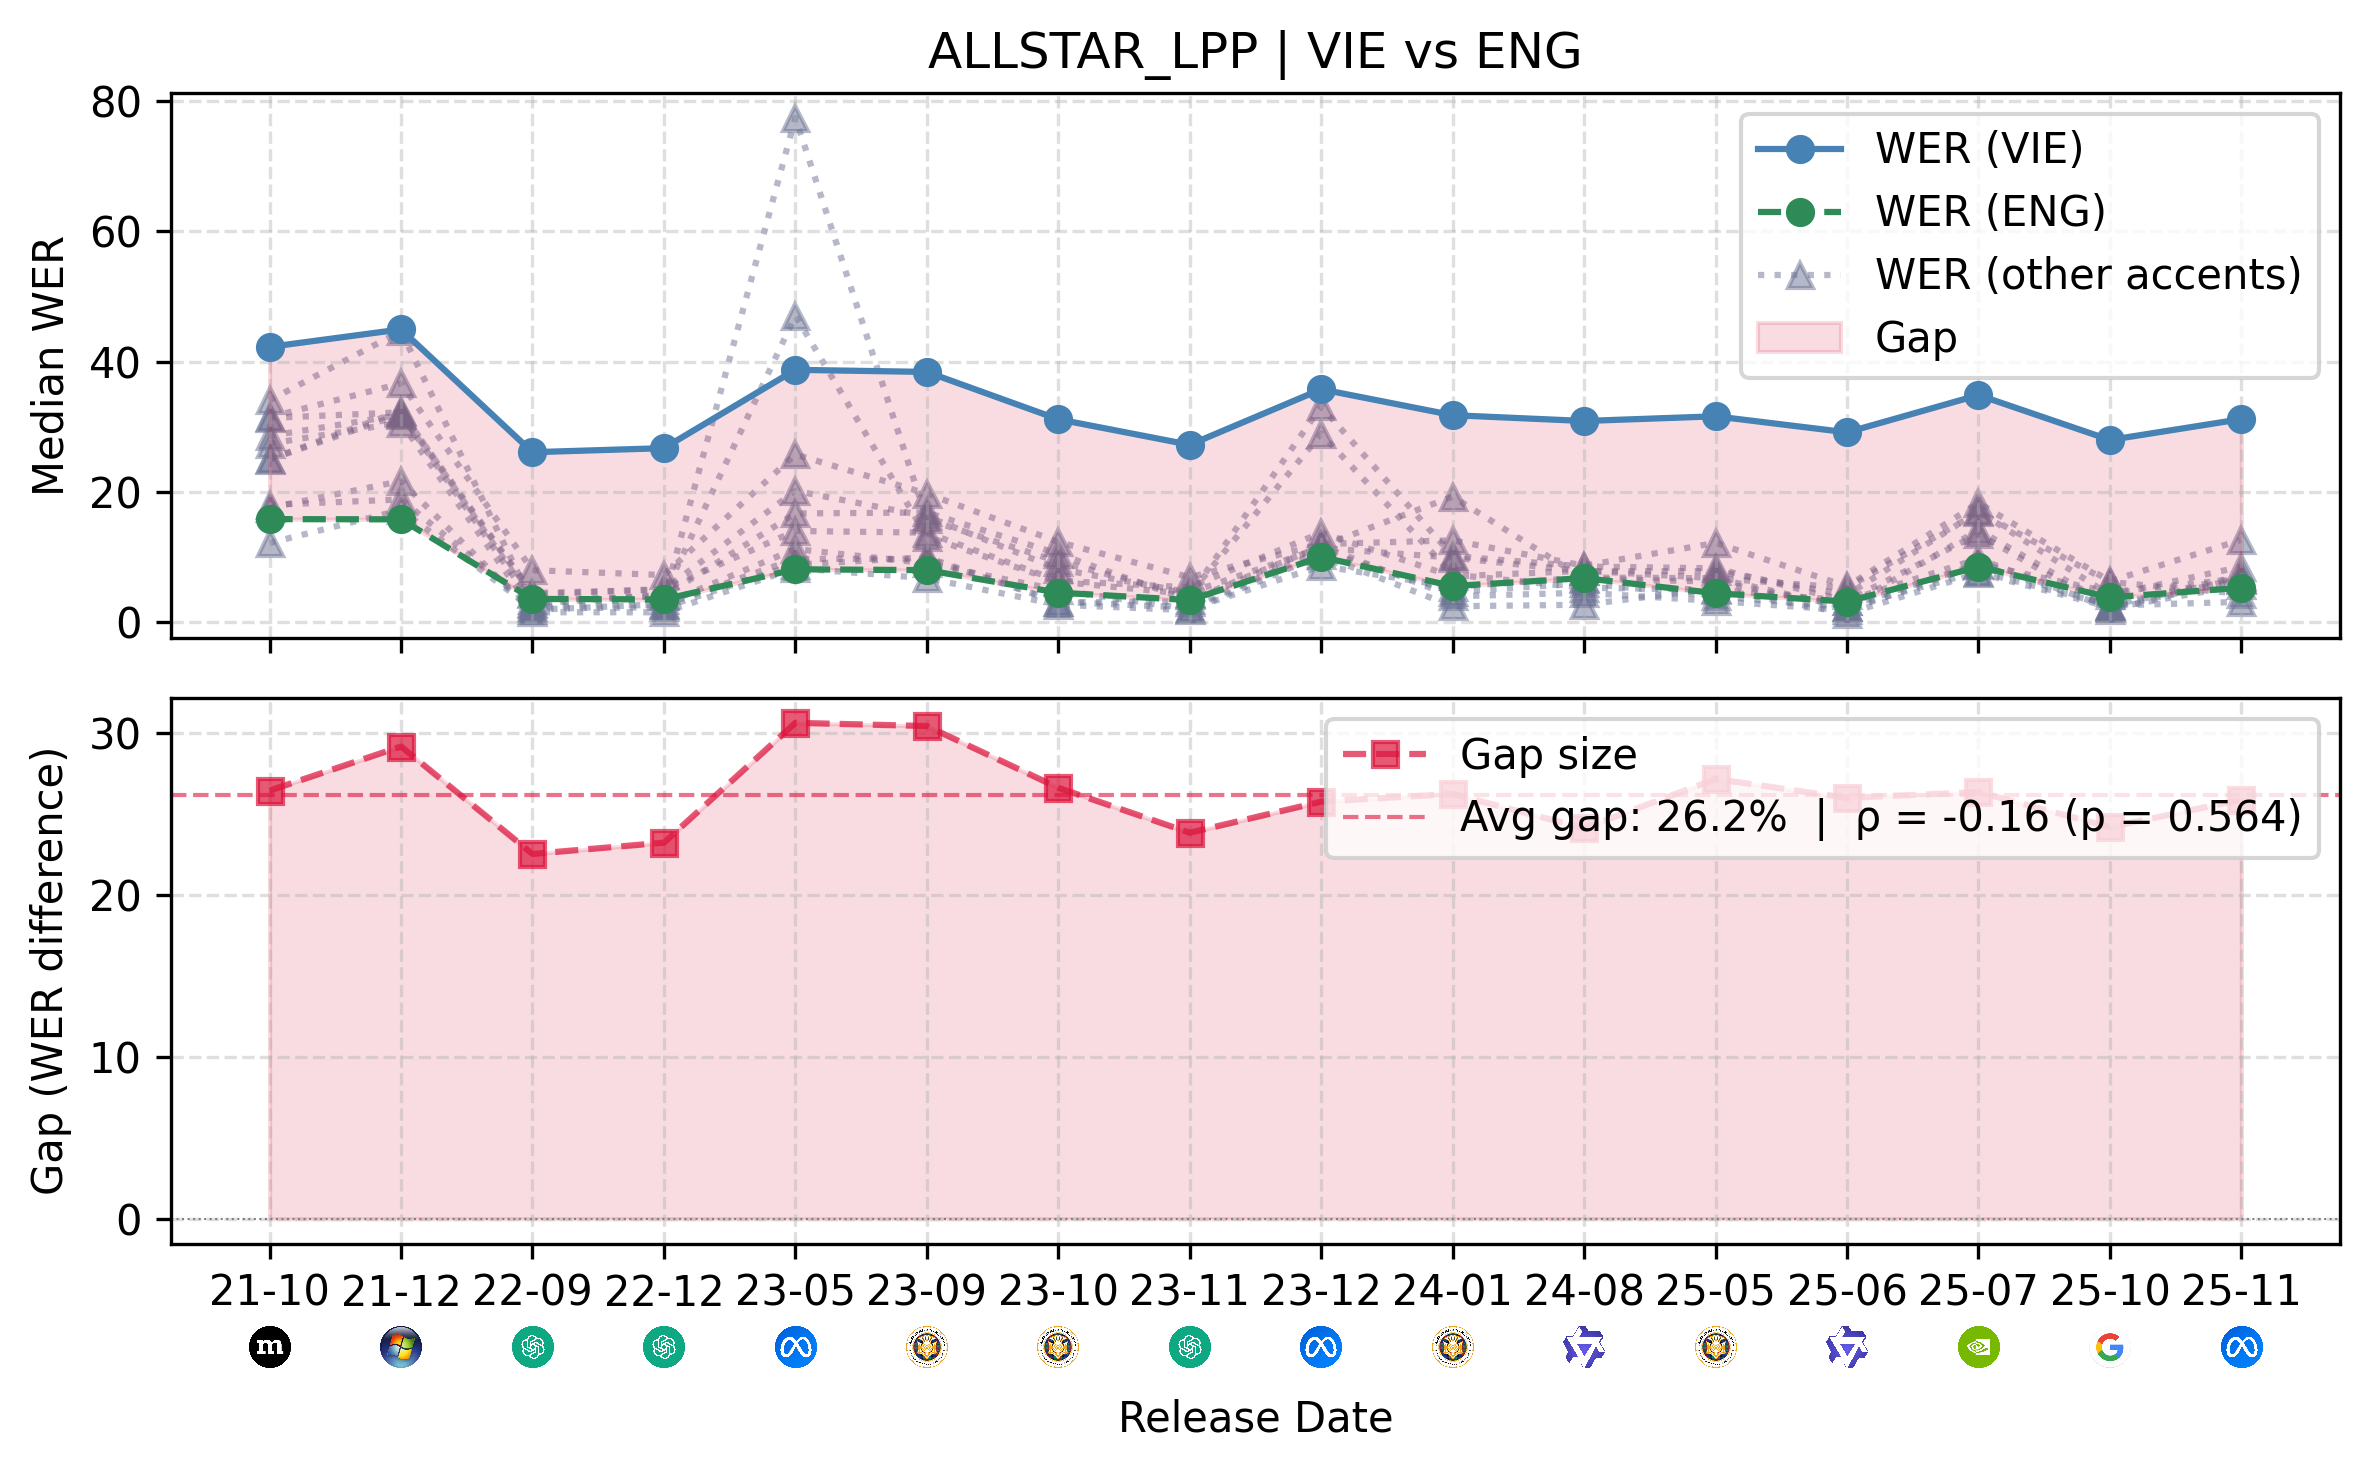

/var/folders/4s/lb1vnqls41q48r0glrfkkhnm0000gn/T/ipykernel_67762/660946607.py:33: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  dataset_frame


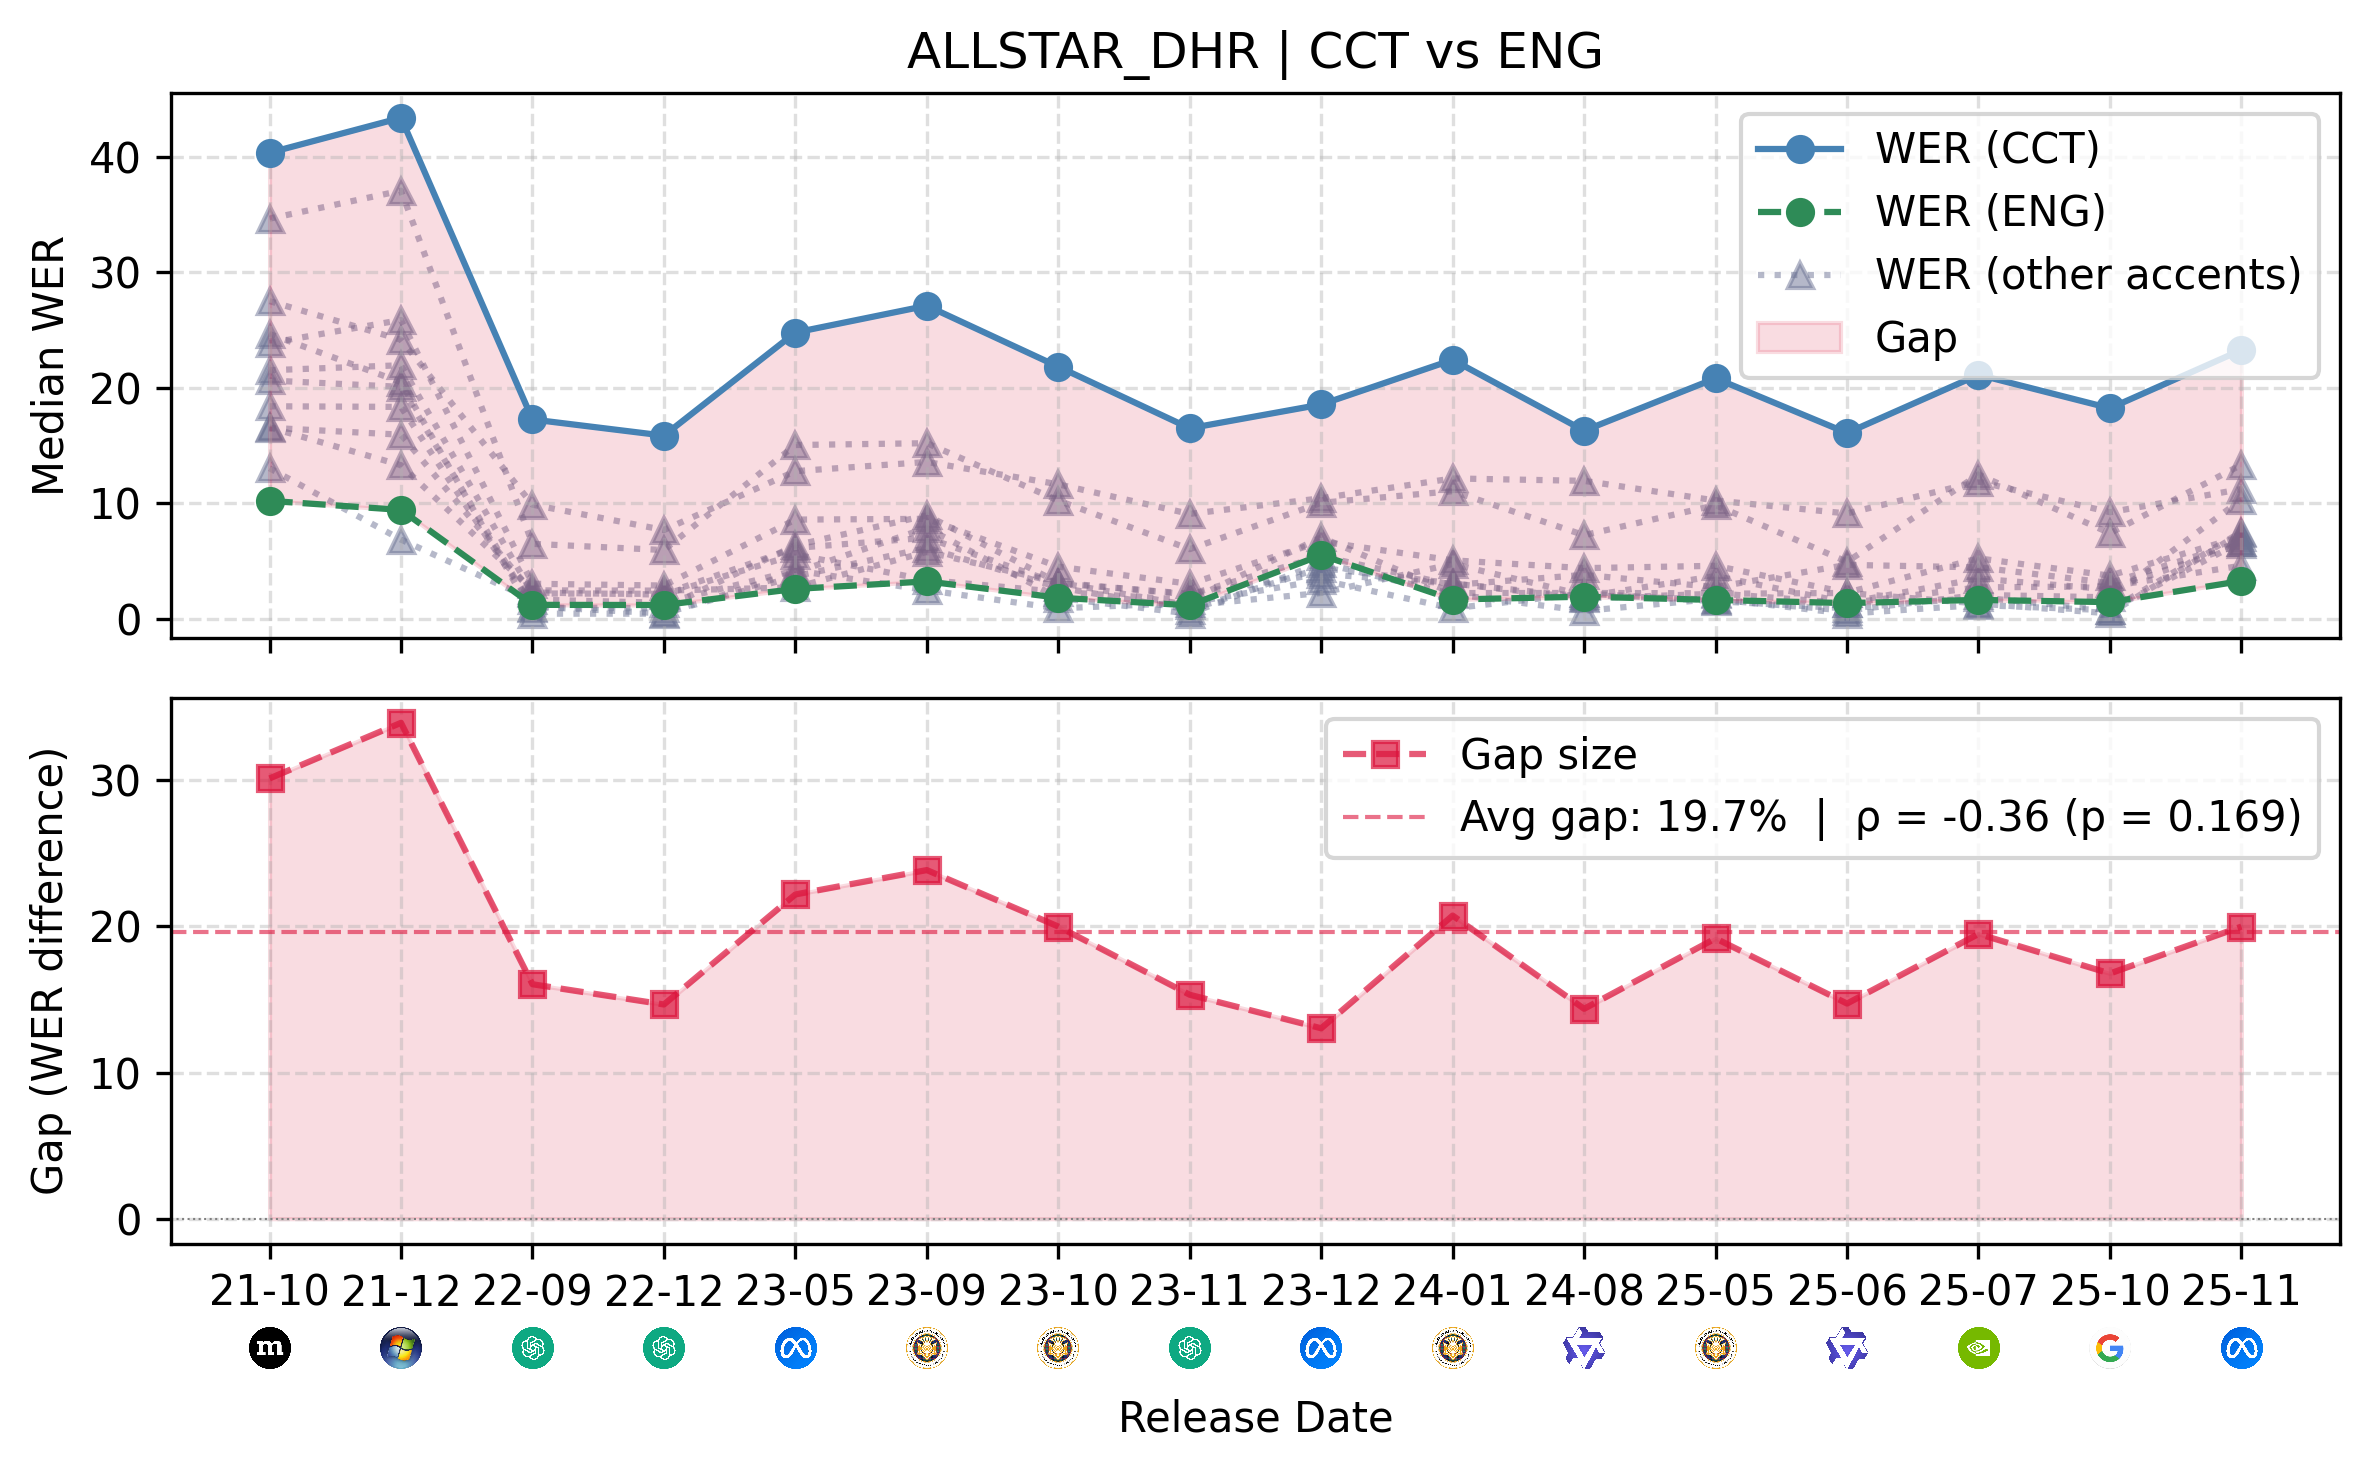

/var/folders/4s/lb1vnqls41q48r0glrfkkhnm0000gn/T/ipykernel_67762/660946607.py:33: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  dataset_frame


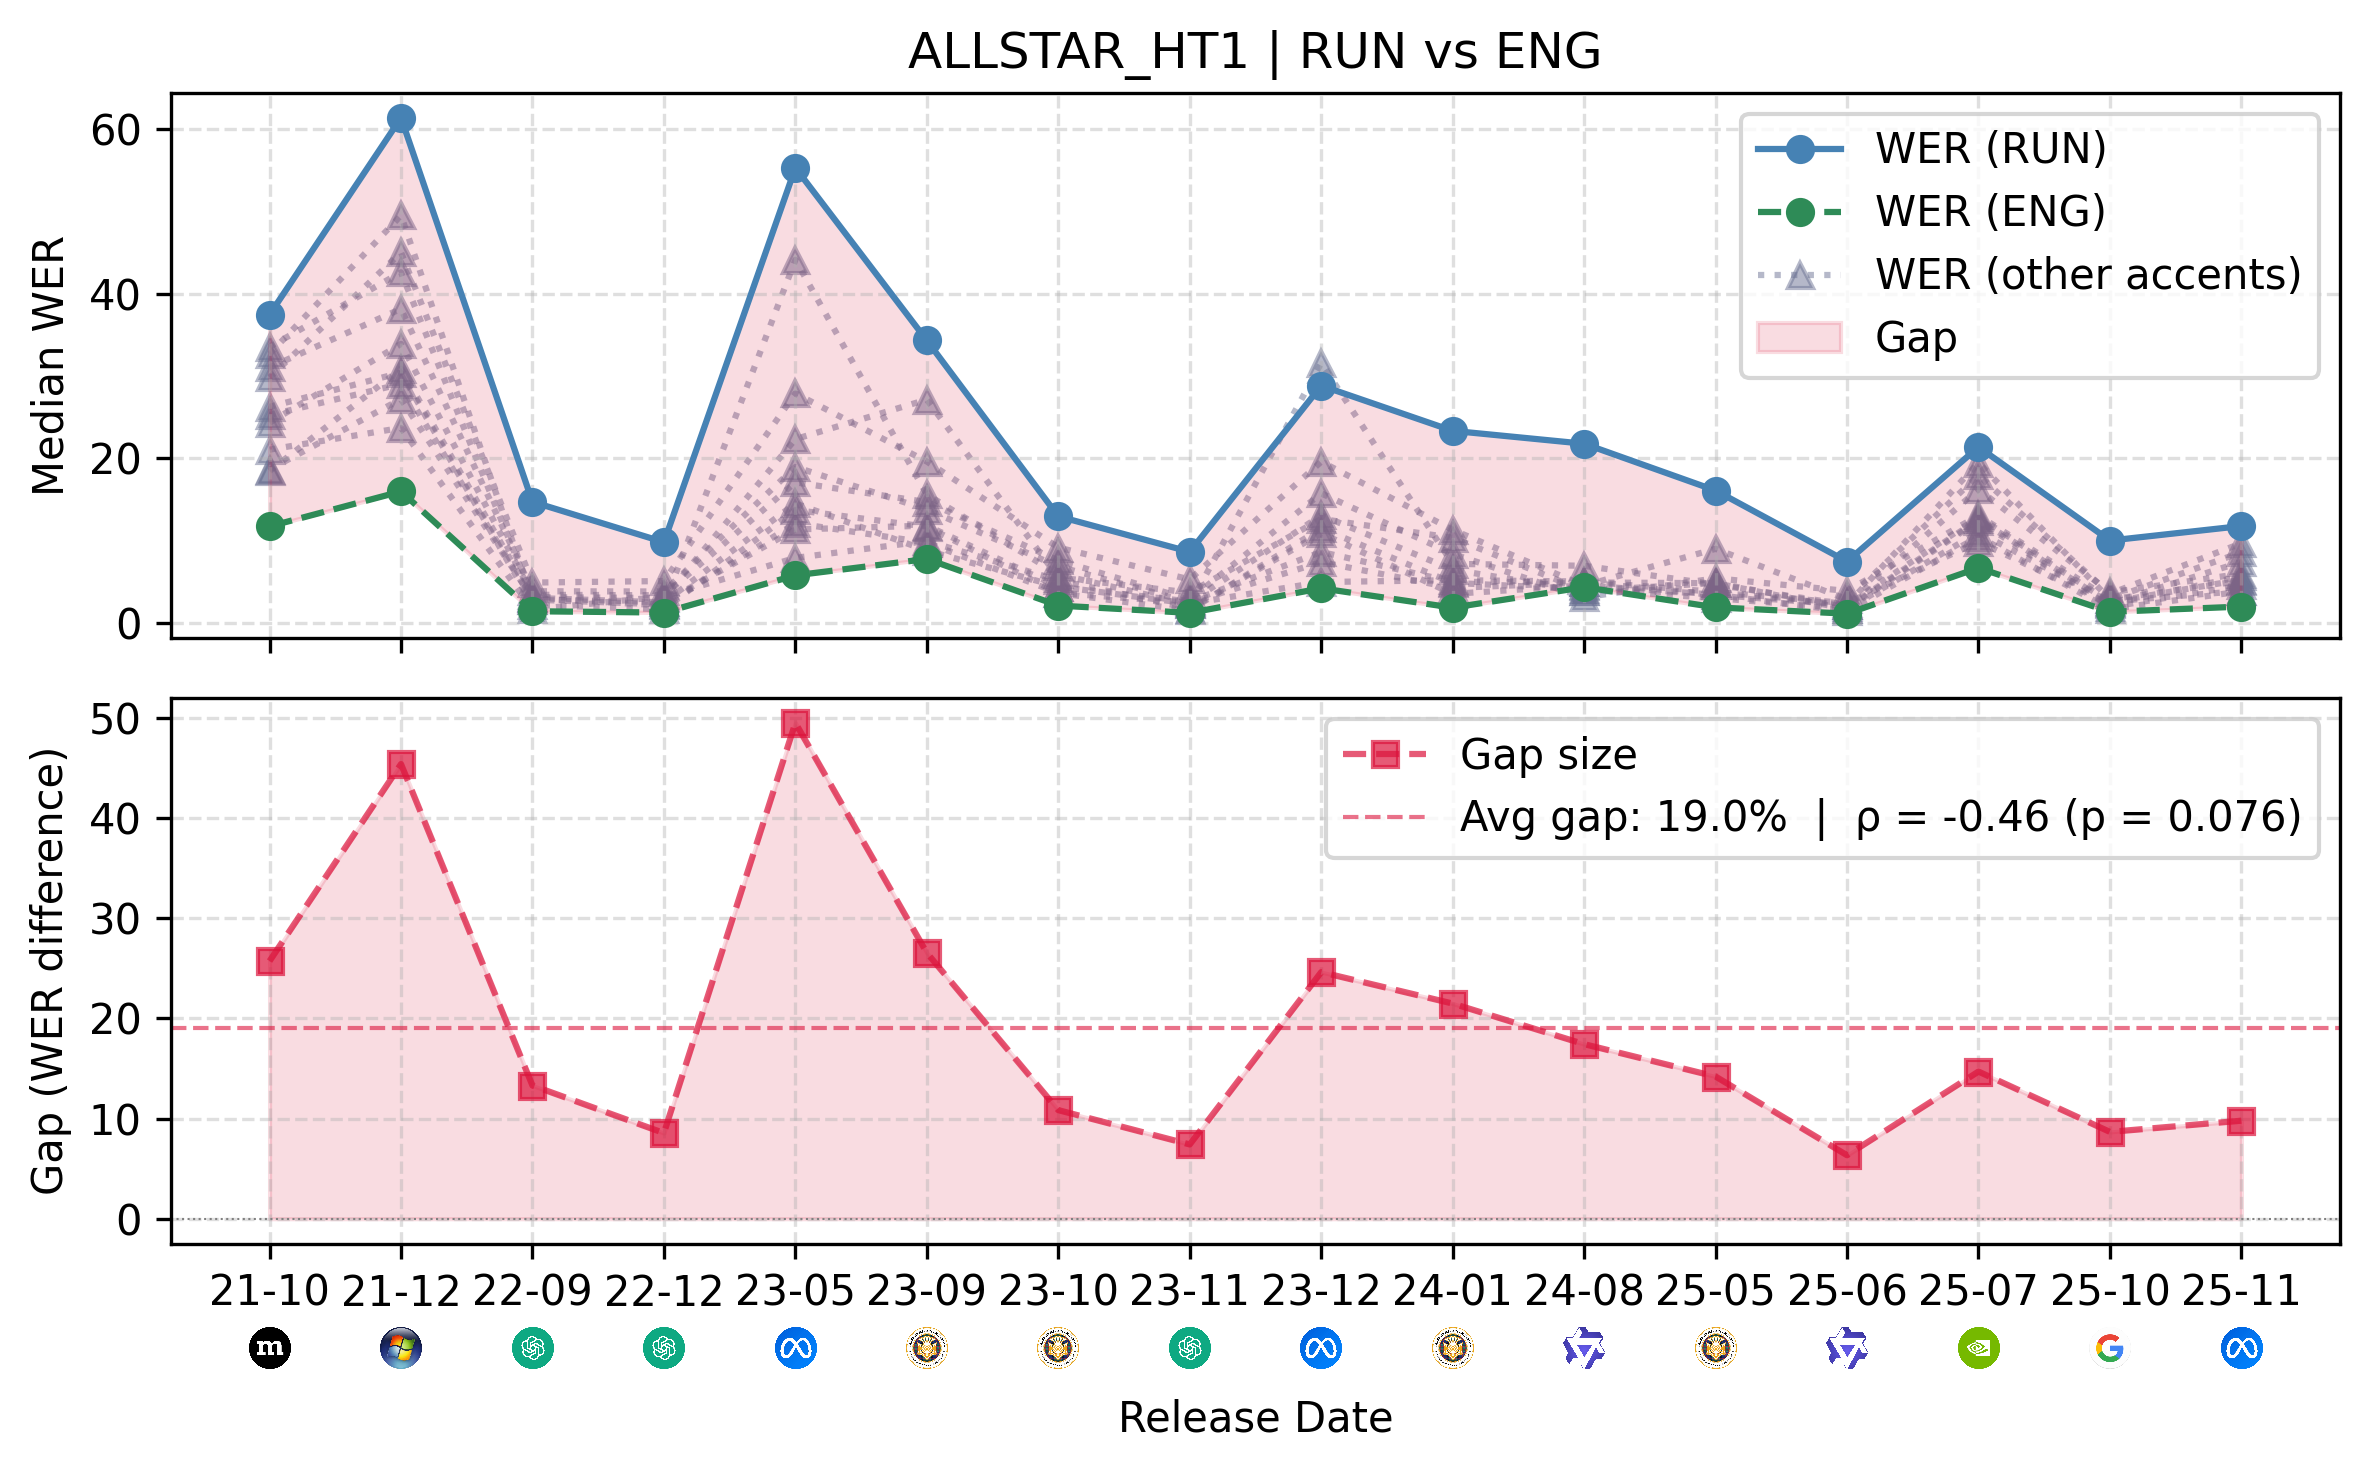

/var/folders/4s/lb1vnqls41q48r0glrfkkhnm0000gn/T/ipykernel_67762/660946607.py:33: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  dataset_frame


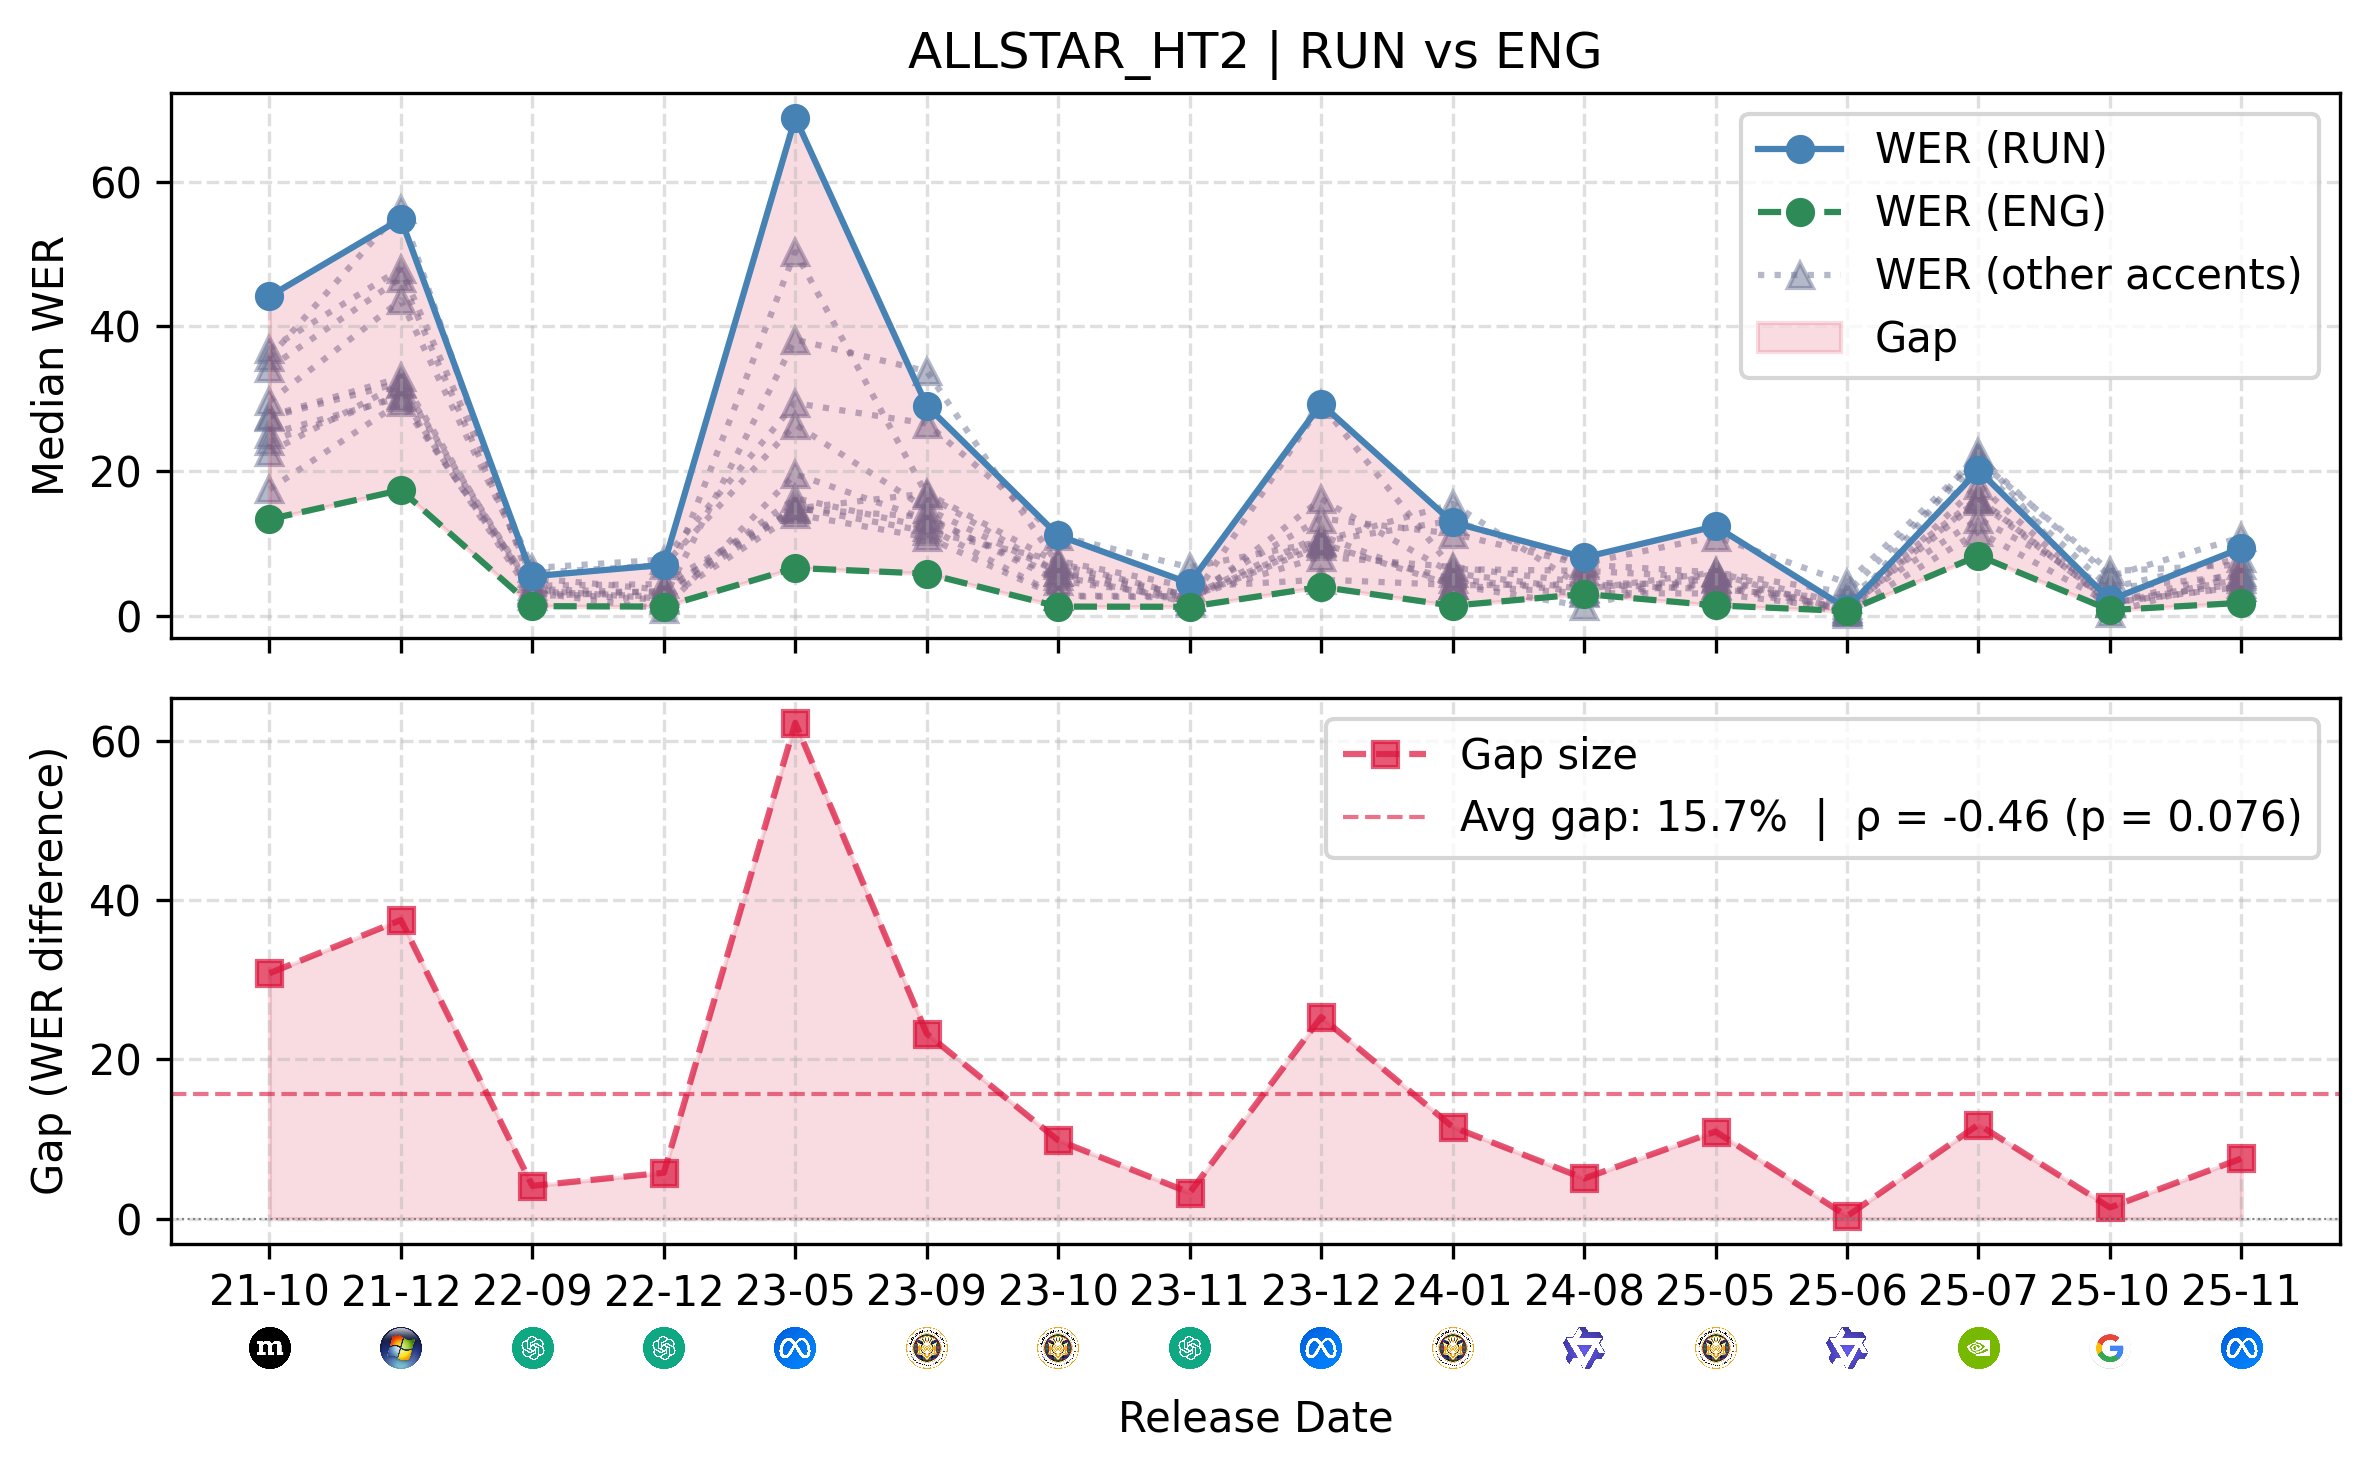

In [78]:
import os
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
MODEL_LOGOS = {
    'Deepspeech': 'logos/mozilla.png',
    'WavLM Libri-100h': 'logos/microsoft.png',
    'Whisper Large v1': 'logos/openai.png',
    'Whisper Large v2': 'logos/openai.png',
    'MMS 1B All': 'logos/meta.png',
    'SeamlessM4T': 'logos/meta.png',
    'Whisper Large v3': 'logos/openai.png',
    'OWSM 1.0 272M': 'logos/cmu.png',
    'OWSM 2.0 739M': 'logos/cmu.png',
    'OWSM 3.1 1B': 'logos/cmu.png',
    'OWSM 4.0 1B': 'logos/cmu.png',
    'Qwen2 Audio 7B': 'logos/qwen.png',
    'Qwen3 ASR 1.7B': 'logos/qwen.png',
    'Qwen3 Audio 14B': 'logos/qwen.png',
    'Canary Qwen 2.5B': 'logos/nvidia.png',
    'Google Chirp 3': 'logos/google.png',
    'Omnilingual 7B': 'logos/meta.png',
}

for (dataset_name, backgrounds) in SPEECHBOX_2_PAIR_MAPPING.items():
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)


    dataset_frame = speechbox_frame.filter(pl.col('dataset_task') == dataset_name)
    dataset_frame = dataset_frame.filter(pl.col('wer') <= 100)  # drop outliers
    minority_background = backgrounds['minority']
    standard_background = backgrounds['standard']
    gap_frame = (
        dataset_frame
        .filter(pl.col('native_language').is_in([minority_background, standard_background]))
        .group_by(['release_date', 'native_language'])
        .agg(pl.col('wer').mean().alias('median_wer'))
        .pivot(index='release_date', columns='native_language', values='median_wer')
        .with_columns(
            (pl.col(minority_background) - pl.col(standard_background)).alias('gap'),
            # change release date to YY-MM format
            pl.col('release_date').str.slice(2).alias('release_date')
            # pl.col('release_date').dt.strftime("%y-%m").alias('release_date_str')
        )
        .sort('release_date')
    )

    release_dates = gap_frame['release_date'].to_list()
    release_index = list(range(len(gap_frame)))
    gap_values = gap_frame['gap'].to_list()
    minority_wer = gap_frame[minority_background].to_list()
    standard_wer = gap_frame[standard_background].to_list()

    x = np.array(release_index, dtype=float)
    y = np.array(gap_values)

    rho, p_value = stats.spearmanr(release_index, gap_values)
    huber = HuberRegressor()
    huber.fit(x.reshape(-1, 1), y)
    m = huber.coef_[0]
    avg_gap = np.mean(gap_values)

    # --- Top panel: WER lines ---
    ax1.plot(release_dates, minority_wer, 'o-', color='steelblue', label=f'WER ({minority_background})')
    ax1.plot(release_dates, standard_wer, 'o--', color='seagreen', label=f'WER ({standard_background})')
    PLOT_TOP_TEN_DIALECTS = True  
    if PLOT_TOP_TEN_DIALECTS:
        all_accents = dataset_frame['native_language'].unique().to_list()
        other_accents = [a for a in all_accents if a not in [minority_background, standard_background]]
        for i, accent in enumerate(other_accents[:10]):
            df_other = (
                speechbox_frame
                .filter(pl.col('wer') <= 100)  # drop outliers
                .with_columns(pl.col('release_date').str.slice(2).alias('release_date'))
                .filter(pl.col('dataset_task') == dataset_name)
                .filter(pl.col('native_language') == accent)
                .group_by(['release_date', 'model'])
                .agg(pl.col('wer').mean().alias('wer_mean'))
                .sort('release_date')
            )
            ax1.plot(df_other['release_date'].to_list(), (df_other['wer_mean']).to_list(),
                    ':^', color=UNCONDITIONAL_COLOR, alpha=0.5,
                    label='WER (other accents)' if i == 0 else None, zorder=-1)
    ax1.fill_between(release_dates, minority_wer, standard_wer, alpha=0.15, color='crimson', label='Gap')
    ax1.set_title(f'{dataset_name} | {minority_background} vs {standard_background}')
    ax1.set_ylabel('Median WER')
    # ax1.set_xticklabels(release_dates, rotation=45, ha='right')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.4)

    # --- Bottom panel: gap ---
    gap_arr = np.array(gap_values)
    ax2.plot(release_dates, gap_arr, 's--', color='crimson', alpha=0.7, label='Gap size')
    ax2.fill_between(release_dates, gap_arr, 0,
                     where=gap_arr > 0,
                     alpha=0.15, color='crimson')
    ax2.axhline(avg_gap, color='crimson', linewidth=1, linestyle='--', alpha=0.6,
                label=f'Avg gap: {avg_gap:.1f}%  |  ρ = {rho:.2f} (p = {p_value:.3f})')
    ax2.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    ax2.set_ylabel('Gap (WER difference)')
    # ax2.set_xticklabels(release_dates, rotation=45, ha='right')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.4)

    if MODEL_LOGOS:
        for x_pos, model in zip(range(len(release_dates)), df_plot['model'].to_list()):
            if model in MODEL_LOGOS:
                im = plt.imread(MODEL_LOGOS[model])
                img = OffsetImage(im, zoom=10 / im.shape[0])
                ab = AnnotationBbox(
                    img, (x_pos, ax2.get_ylim()[0]),
                    frameon=False, box_alignment=(0.5, 0.5),
                    xybox=(0., -25.), boxcoords="offset points",
                )
                ax2.add_artist(ab)
    ax2.set_xlabel('Release Date', labelpad=20)
    # plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()

    save_dir = "aies_plots"
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(os.path.join(save_dir, f'{dataset_name}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


    

# Within-family analysis

In [164]:

FAMILIES = {
    "WHISPER": ['Whisper Large v1', 'Whisper Large v2', 'Whisper Large v3'],
    "META": ["MMS 1B All", "SeamlessM4T", "Omnilingual 7B"], 
    "OWSM": ["OWSM 1.0 272M", "OWSM 2.0 739M", "OWSM 3.1 1B", "OWSM 4.0 1B"],
    "QWEN": ["Qwen2 Audio 7B", "Qwen3 Audio 14B", "Canary Qwen 2.5B"],
}

WHISPER - Average gap increase size for spikes: 0.00%
WHISPER - Pearson r: -0.078, p-value: 0.221
META - Average gap increase size for spikes: 5.53%
META - Pearson r: -0.381, p-value: 0.000
OWSM - Average gap increase size for spikes: 3.00%
OWSM - Pearson r: -0.385, p-value: 0.000
QWEN - Average gap increase size for spikes: 11.09%
QWEN - Pearson r: 0.297, p-value: 0.000


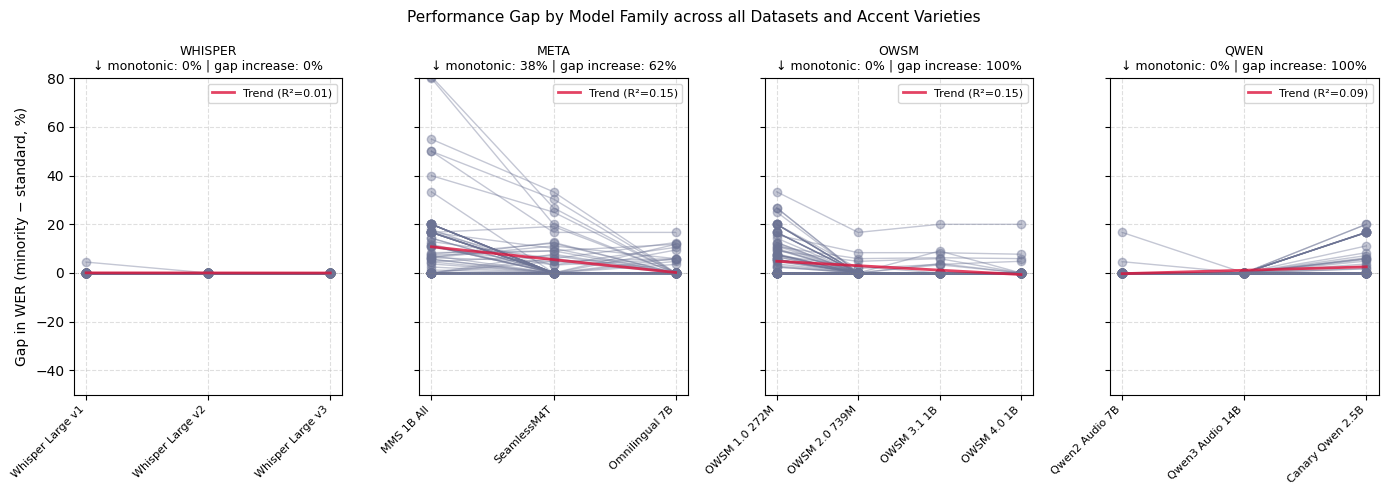

In [166]:
from cycler import cycler
from scipy.stats import pearsonr, spearmanr

plt.style.use('seaborn-v0_8-colorblind')


# Get current property cycle (the seaborn colorblind palette)
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# Add an extra color
extra_color = "#6C7394"  
colors.append(extra_color)

# Set the new color cycle
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
UNCONDITIONAL_COLOR = colors[-1]

fig, axes = plt.subplots(1, len(FAMILIES), figsize=(14, 5), sharey=True)

# combine DATASET_2_PAIR_MAPPING

for ax, (family_name, family_models) in zip(axes, FAMILIES.items()):
    
    gap_increase_sizes = []
    n_monotonic = 0
    n_spike = 0
    all_x = []
    all_gaps = []

    for dataset_name, backgrounds in SPEECHBOX_2_PAIR_MAPPING.items():
        dataset_frame = speechbox_frame.filter(pl.col('dataset_task') == dataset_name)
        
        # multiply WER by 100
        dataset_frame = dataset_frame.with_columns(pl.col('wer') * 100)
        
        standard_background = backgrounds['standard']
        
        family_frame = dataset_frame.filter(pl.col('model').is_in(family_models))
        
        if family_frame.is_empty():
            continue

        all_accents = family_frame['native_language'].unique().to_list()
        minority_accents = [a for a in all_accents if a != standard_background]

        standard_frame = (
            family_frame
            .filter(pl.col('native_language') == standard_background)
            .group_by(['model', 'release_date'])
            .agg(pl.col('wer').median().alias('median_wer'))
            .sort('release_date')
        )

        for accent in minority_accents:
            minority_frame = (
                family_frame
                .filter(pl.col('native_language') == accent)
                .group_by(['model', 'release_date'])
                .agg(pl.col('wer').median().alias('median_wer'))
                .sort('release_date')
            )

            merged = minority_frame.join(standard_frame, on=['model', 'release_date'], suffix='_standard')
            
            if len(merged) < 2:
                continue
            
            merged = merged.with_columns(
                (pl.col('median_wer') - pl.col('median_wer_standard')).alias('gap')
            ).sort('release_date')

            gap = merged['gap'].to_list()
            deltas = [gap[i+1] - gap[i] for i in range(len(gap) - 1)]

            # Monotonic decrease: all deltas negative
            if all(d < 0 for d in deltas):
                n_monotonic += 1
            # Spike: any increase at positions 2, 3, or 4 (i.e. delta index 1, 2, 3)
            elif any(deltas[i] > 0 for i in range(1, len(deltas))):
                n_spike += 1

            gap_increase_sizes.extend([d for i, d in enumerate(deltas) if i >= 1 and d > 0])
            x = list(range(len(merged)))
            gap_vals = merged['gap'].to_list()
            all_x.extend(x)
            all_gaps.extend(gap_vals)
            ax.plot(x, gap_vals, 'o-', alpha=0.4, linewidth=1, color=UNCONDITIONAL_COLOR)

    total = n_monotonic + n_spike
    pct_monotonic = 100 * n_monotonic / total if total > 0 else 0
    pct_spike = 100 * n_spike / total if total > 0 else 0
    # avg gap increase size for spikes
    avg_gap_increase = np.mean(gap_increase_sizes) if gap_increase_sizes else 0
    print(f"{family_name} - Average gap increase size for spikes: {avg_gap_increase:.2f}%")

    ax.set_xticks(range(len(family_models)))
    ax.set_xticklabels(family_models, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"{family_name}\n↓ monotonic: {pct_monotonic:.0f}% | gap increase: {pct_spike:.0f}%", fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    # set ylim to -0.5 to 0.8
    ax.set_ylim(-50, 80)
    ax.grid(True, linestyle='--', alpha=0.4)

    all_x = np.array(all_x)
    all_gaps = np.array(all_gaps)
    m, b = np.polyfit(all_x, all_gaps, 1)
    x_smooth = np.linspace(0, len(family_models) - 1, 100)
    r, p = pearsonr(all_x, all_gaps)
    print(f"{family_name} - Pearson r: {r:.3f}, p-value: {p:.3f}")

    predicted = m * all_x + b
    ss_res = np.sum((all_gaps - predicted) ** 2)
    ss_tot = np.sum((all_gaps - np.mean(all_gaps)) ** 2)
    r2 = 1 - ss_res / ss_tot

    x_smooth = np.linspace(0, len(family_models) - 1, 100)
    ax.plot(x_smooth, m * x_smooth + b, '-', color='crimson', linewidth=2, alpha=0.8, label=f'Trend (R²={r2:.2f})')
    ax.legend(fontsize=8)

    #Make sure all_x and all_gaps are reset to [] at the start of each family loop, not inside


axes[0].set_ylabel('Gap in WER (minority − standard, %)')
fig.suptitle('Performance Gap by Model Family across all Datasets and Accent Varieties', fontsize=11)
plt.tight_layout()
plt.show()

## Finding individual examples

In [13]:

# speechbox_raw_frame =pl.read_csv('allstar_wer_1128_filtered.csv')
speechbox_raw_frame =pl.read_csv('post_rebuttal_results/allstar_wer_0314_filtered.csv')
print(speechbox_raw_frame.columns)

['filepath', 'speaker', 'gender', 'l1', 'task', 'text', 'normalized_text_whisper_large_v1', 'normalized_text_whisper_large_v2', 'normalized_text_whisper_large_v3', 'normalized_text_canary', 'normalized_text_mms_1b', 'normalized_text_qwen2_audio', 'text_normalized', 'normalized_text_omni', 'normalized_text_wavlm', 'normalized_text_owsm_v1', 'normalized_text_owsm_v2_ebranchformer', 'normalized_text_owsm_v3_1_ebf', 'normalized_text_owsm_v4_medium_1b', 'normalized_text_seamless_m4t_v2_large', 'normalized_text_google_speech', 'normalized_text_deepspeech', 'normalized_text_qwen3_audio', 'wer_whisper_large_v1', 'wer_whisper_large_v2', 'wer_whisper_large_v3', 'wer_canary', 'wer_mms_1b', 'wer_qwen2_audio', 'wer_omni', 'wer_wavlm', 'wer_owsm_v1', 'wer_owsm_v2_ebranchformer', 'wer_owsm_v3_1_ebf', 'wer_owsm_v4_medium_1b', 'wer_seamless_m4t_v2_large', 'wer_google_speech', 'wer_deepspeech', 'wer_qwen3_audio']


In [14]:
speechbox_frame['model'].unique().to_list()
speechbox_frame['dataset'].unique().to_list()

# add the 'LPP', 'DHR', 'HT1', 'HT2' task suffixes to the dataset column in the raw frame
speechbox_frame = speechbox_frame.with_columns([
    (pl.col('dataset') + '_' + pl.col('task')).alias('dataset')
])

### HT1

In [19]:
ht1_frame = speechbox_raw_frame.filter((pl.col('task')=='HT1') & (pl.col('l1')=='RUN'))
ht1_frame = ht1_frame.with_columns([
    (pl.col('wer_canary') - pl.col('wer_whisper_large_v1')).alias('canary_degradation_wer')
])
ht1_frame = ht1_frame.sort('canary_degradation_wer', descending=True).head(len(ht1_frame) // 4)
# get the top quartile of rows with highest canary_degradation_wer

print(get_regression_size_for_models(
    speechbox_frame, 
    'ALLSTAR_LPP', 
    'RUN', 
    'Whisper Large v3', 
    'OWSM 3.1 1B'
))

print(get_regression_size_for_models(
    speechbox_frame, 
    'ALLSTAR_LPP', 
    'ENG', 
    'Whisper Large v3', 
    'OWSM 3.1 1B'
))


0.06052439623868194
0.021520461819193863


In [20]:
def print_random_row(frame, prev_model, later_model):
    # get a random row 
    random_row = frame.sample(n=1, with_replacement=False)
    # print the filepath
    print("Filepath: ", random_row['filepath'][0])
    print("\n\n\n\n")
    # print the whisper v1 text and the canary text
    print(f"{prev_model} Text: ", random_row[f'normalized_text_{prev_model}'][0])
    print(f"{later_model} Normalized Text: ", random_row[f'normalized_text_{later_model}'][0])
    print(f"Ground truth: ", random_row['text_normalized'][0])
print_random_row(ht1_frame, 'whisper_large_v1', 'canary')

Filepath:  segmented_audio/ALL_RUN_ENG_HT1_ALL_116_M_RUN_ENG_HT1_seg056.wav





whisper_large_v1 Text:  the lady washed the shirt
canary Normalized Text:  the lady was the chart
Ground truth:  the lady washed the shirt


## HT2 

In [351]:
ht2_frame = speechbox_raw_frame.filter((pl.col('task')=='HT2') & (pl.col('l1')=='RUN'))
ht2_frame = ht2_frame.with_columns([
    (pl.col('wer_omni') - pl.col('wer_whisper_large_v1')).alias('omni_degradation_wer')
])
ht2_frame = ht2_frame.sort('omni_degradation_wer', descending=True).head(len(ht2_frame) // 4)

In [353]:
ht2_frame.columns

['filepath',
 'speaker',
 'gender',
 'l1',
 'task',
 'text',
 'normalized_text_whisper_large_v1',
 'normalized_text_whisper_large_v2',
 'normalized_text_whisper_large_v3',
 'normalized_text_canary',
 'normalized_text_mms_1b',
 'normalized_text_owsm_3_1',
 'normalized_text_qwen2_audio',
 'text_normalized',
 'wer_whisper_large_v1',
 'wer_whisper_large_v2',
 'wer_whisper_large_v3',
 'wer_canary',
 'wer_mms_1b',
 'wer_owsm_3_1',
 'wer_qwen2_audio',
 'normalized_text_omni',
 'normalized_text_wavlm',
 'wer_omni',
 'wer_wavlm',
 'omni_degradation_wer']

In [355]:
print_random_row(ht2_frame, 'whisper_large_v1', 'omni')

Filepath:  segmented_audio/ALL_RUN_ENG_HT2_ALL_116_M_RUN_ENG_HT2_seg032.wav









whisper_large_v1 Text:  he is washing his face with soap
omni Normalized Text:  he is washing his face with sore
Ground truth:  he is washing his face with soap


## Le Petit Prince

In [361]:
# get the LPP task
lpp_frame = speechbox_raw_frame.filter((pl.col('task')=='LPP') & (pl.col('l1')=='VIE'))
lpp_frame = lpp_frame.with_columns([
    (pl.col('wer_omni') - pl.col('wer_qwen2_audio')).alias('omni_degradation_wer')
])
lpp_frame = lpp_frame.sort('omni_degradation_wer', descending=True).head(len(lpp_frame) // 4)

In [369]:
print_random_row(lpp_frame, 'whisper_large_v2', 'canary')

Filepath:  segmented_audio/ALL_VIE_ENG_LPP_ALL_031_M_VIE_ENG_LPP_seg003.wav









whisper_large_v2 Text:  draw me a sheep
canary Normalized Text:  turn me a say
Ground truth:  draw me a sheep


## DHR

In [371]:
# Get the DHR task
dhr_frame = speechbox_raw_frame.filter((pl.col('task')=='DHR') & (pl.col('l1')=='CCT'))
dhr_frame = dhr_frame.with_columns([
    (pl.col('wer_owsm_3_1') - pl.col('wer_whisper_large_v3')).alias('owsm_degradation_wer')
])
dhr_frame = dhr_frame.sort('owsm_degradation_wer', descending=True).head(len(dhr_frame) // 4)
print_random_row(dhr_frame, 'whisper_large_v3', 'owsm_3_1')

Filepath:  segmented_audio/ALL_CCT_ENG_DHR_ALL_086_F_CCT_ENG_DHR_seg006.wav









whisper_large_v3 Text:  everyone has the right to a nationality
owsm_3_1 Normalized Text:  every one has to wai t t t snr t
Ground truth:  everyone has the right to a nationality
